In [1440]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score


In [1441]:
# Load the dataset
housing_data = pd.read_csv('housing_data.csv')

In [1442]:
housing_data

,Unnamed: 0,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,0,SC60,RL,65,8450,Pave,None,Reg,Lvl,AllPub,...,0,No,No,No,0,Feb,2008,WD,Normal,208500
1,1,SC20,RL,80,9600,Pave,None,Reg,Lvl,AllPub,...,0,No,No,No,0,May,2007,WD,Normal,181500
2,2,SC60,RL,68,11250,Pave,None,IR1,Lvl,AllPub,...,0,No,No,No,0,Sep,2008,WD,Normal,223500
3,3,SC70,RL,60,9550,Pave,None,IR1,Lvl,AllPub,...,0,No,No,No,0,Feb,2006,WD,Abnorml,140000
4,4,SC60,RL,84,14260,Pave,None,IR1,Lvl,AllPub,...,0,No,No,No,0,Dec,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1455,SC60,RL,62,7917,Pave,None,Reg,Lvl,AllPub,...,0,No,No,No,0,Aug,2007,WD,Normal,175000
1456,1456,SC20,RL,85,13175,Pave,None,Reg,Lvl,AllPub,...,0,No,MnPrv,No,0,Feb,2010,WD,Normal,210000
1457,1457,SC70,RL,66,9042,Pave,None,Reg,Lvl,AllPub,...,0,No,GdPrv,Shed,2500,May,2010,WD,Normal,266500
1458,1458,SC20,RL,68,9717,Pave,None,Reg,Lvl,AllPub,...,0,No,No,No,0,Apr,2010,WD,Normal,142125


In [1443]:
# Show first 5 rows
housing_data.head()

,Unnamed: 0,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,0,SC60,RL,65,8450,Pave,None,Reg,Lvl,AllPub,...,0,No,No,No,0,Feb,2008,WD,Normal,208500
1,1,SC20,RL,80,9600,Pave,None,Reg,Lvl,AllPub,...,0,No,No,No,0,May,2007,WD,Normal,181500
2,2,SC60,RL,68,11250,Pave,None,IR1,Lvl,AllPub,...,0,No,No,No,0,Sep,2008,WD,Normal,223500
3,3,SC70,RL,60,9550,Pave,None,IR1,Lvl,AllPub,...,0,No,No,No,0,Feb,2006,WD,Abnorml,140000
4,4,SC60,RL,84,14260,Pave,None,IR1,Lvl,AllPub,...,0,No,No,No,0,Dec,2008,WD,Normal,250000


In [1444]:
# show last 5 rows
housing_data.tail()

,Unnamed: 0,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,1455,SC60,RL,62,7917,Pave,None,Reg,Lvl,AllPub,...,0,No,No,No,0,Aug,2007,WD,Normal,175000
1456,1456,SC20,RL,85,13175,Pave,None,Reg,Lvl,AllPub,...,0,No,MnPrv,No,0,Feb,2010,WD,Normal,210000
1457,1457,SC70,RL,66,9042,Pave,None,Reg,Lvl,AllPub,...,0,No,GdPrv,Shed,2500,May,2010,WD,Normal,266500
1458,1458,SC20,RL,68,9717,Pave,None,Reg,Lvl,AllPub,...,0,No,No,No,0,Apr,2010,WD,Normal,142125
1459,1459,SC20,RL,75,9937,Pave,None,Reg,Lvl,AllPub,...,0,No,No,No,0,Jun,2008,WD,Normal,147500


In [1445]:
housing_data.shape

(1460, 81)

In [1446]:
#check the variables
housing_data.columns

Index(['Unnamed: 0', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea',
       'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'Pa

In [1447]:
# Rename the columns for better understanding:
rename_col = {'MSSubClass':'Identifies_the_type_of_dwelling','LotConfig':'Lot_configuration','BldgType':'Type_of_dwelling',
              'RoofMatl':'Roof_material','MasVnrType':'Masonry_veneer_type',
              'Electrical':'Electrical_system','LowQualFinSF':'Low_quality_finished_square_feet',
              'KitchenQual':'Kitchen_Quality','GarageType':'Garage_location',
              'GarageCond':'Garage_condition','PavedDrive':'Paved driveway',
              'PoolQC':'Pool_quality','Fence':'Fence_Quality',
              'MiscFeature':'Miscellaneous_feature','MiscVal':'miscellaneous_feature'}

In [1448]:
housing_data=housing_data.rename(columns=rename_col)
housing_data.head()

,Unnamed: 0,Identifies_the_type_of_dwelling,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,Pool_quality,Fence_Quality,Miscellaneous_feature,miscellaneous_feature,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,0,SC60,RL,65,8450,Pave,None,Reg,Lvl,AllPub,...,0,No,No,No,0,Feb,2008,WD,Normal,208500
1,1,SC20,RL,80,9600,Pave,None,Reg,Lvl,AllPub,...,0,No,No,No,0,May,2007,WD,Normal,181500
2,2,SC60,RL,68,11250,Pave,None,IR1,Lvl,AllPub,...,0,No,No,No,0,Sep,2008,WD,Normal,223500
3,3,SC70,RL,60,9550,Pave,None,IR1,Lvl,AllPub,...,0,No,No,No,0,Feb,2006,WD,Abnorml,140000
4,4,SC60,RL,84,14260,Pave,None,IR1,Lvl,AllPub,...,0,No,No,No,0,Dec,2008,WD,Normal,250000


In [1449]:
housing_data.columns

Index(['Unnamed: 0', 'Identifies_the_type_of_dwelling', 'MSZoning',
       'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour',
       'Utilities', 'Lot_configuration', 'LandSlope', 'Neighborhood',
       'Condition1', 'Condition2', 'Type_of_dwelling', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'Roof_material', 'Exterior1st', 'Exterior2nd', 'Masonry_veneer_type',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical_system', '1stFlrSF', '2ndFlrSF',
       'Low_quality_finished_square_feet', 'GrLivArea', 'BsmtFullBath',
       'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr',
       'Kitchen_Quality', 'TotRmsAbvGrd', 'Functional', 'Fireplaces',
       'FireplaceQu', 'Garage_location', 'Ga

In [1450]:
housing_data.shape

(1460, 81)

In [1451]:
housing_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Unnamed: 0                        1460 non-null   int64  
 1   Identifies_the_type_of_dwelling   1460 non-null   object 
 2   MSZoning                          1460 non-null   object 
 3   LotFrontage                       1460 non-null   int64  
 4   LotArea                           1460 non-null   int64  
 5   Street                            1460 non-null   object 
 6   Alley                             1460 non-null   object 
 7   LotShape                          1460 non-null   object 
 8   LandContour                       1460 non-null   object 
 9   Utilities                         1460 non-null   object 
 10  Lot_configuration                 1460 non-null   object 
 11  LandSlope                         1460 non-null   object 
 12  Neighb

In [1452]:
# Get the desciptive statistics summary of my data:

In [1453]:
housing_data.describe()

,Unnamed: 0,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,miscellaneous_feature,YrSold,SalePrice
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,729.500000,57.623288,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.117123,443.639726,46.549315,...,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,2007.815753,180921.195890
std,421.610009,34.664304,9981.264932,1.382997,1.112799,30.202904,20.645407,180.731373,456.098091,161.319273,...,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,1.328095,79442.502883
min,0.000000,0.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2006.000000,34900.000000
25%,364.750000,42.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,...,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2007.000000,129975.000000
50%,729.500000,63.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,...,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2008.000000,163000.000000
75%,1094.250000,79.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,164.250000,712.250000,0.000000,...,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2009.000000,214000.000000
max,1459.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,...,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,2010.000000,755000.000000


In [1454]:
# 2. Cleaning the data:
# Check the Duplicates In the dateset:
housing_data = housing_data.drop_duplicates()
housing_data.count()

Unnamed: 0                         1460
Identifies_the_type_of_dwelling    1460
MSZoning                           1460
LotFrontage                        1460
LotArea                            1460
                                   ... 
MoSold                             1460
YrSold                             1460
SaleType                           1460
SaleCondition                      1460
SalePrice                          1460
Length: 81, dtype: int64

In [1455]:
# Check the Null-values:
housing_data.isnull().sum().iloc[51:81]

BedroomAbvGr              0
KitchenAbvGr              0
Kitchen_Quality           0
TotRmsAbvGrd              0
Functional                0
Fireplaces                0
FireplaceQu               0
Garage_location           0
GarageYrBlt              81
GarageFinish              0
GarageCars                0
GarageArea                0
GarageQual                0
Garage_condition          0
Paved driveway            0
WoodDeckSF                0
OpenPorchSF               0
EnclosedPorch             0
3SsnPorch                 0
ScreenPorch               0
PoolArea                  0
Pool_quality              0
Fence_Quality             0
Miscellaneous_feature     0
miscellaneous_feature     0
MoSold                    0
YrSold                    0
SaleType                  0
SaleCondition             0
SalePrice                 0
dtype: int64

In [1456]:
# Drop the missing values & Columns:
housing_data['Alley'].isnull().mean()*100

0.0

In [1457]:
housing_data['GarageYrBlt'].isnull().mean()*100

5.5479452054794525

In [1458]:
housing_data['Masonry_veneer_type'].isnull().mean()*100

0.0

In [1459]:
housing_data['Electrical_system'].isnull().mean()*100

0.0684931506849315

In [1460]:
# Check the Null-Values in columns:
housing_data[housing_data['Electrical_system'].isnull()].iloc[:,30:50]

,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical_system,1stFlrSF,2ndFlrSF,Low_quality_finished_square_feet,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath
1379,Gd,TA,No,Unf,0,Unf,0,384,384,GasA,Gd,Y,NaN,754,640,0,1394,0,0,2


In [1461]:
housing_data['Electrical_system'].value_counts()

SBrkr    1334
FuseA      94
FuseF      27
FuseP       3
Mix         1
Name: Electrical_system, dtype: int64

In [1462]:
housing_data[housing_data['GarageYrBlt'].isnull()].iloc[:,30:50]

,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical_system,1stFlrSF,2ndFlrSF,Low_quality_finished_square_feet,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath
39,No,No,No,No,0,No,0,0,0,GasA,TA,N,FuseP,1152,0,0,1152,0,0,2
48,TA,TA,No,Unf,0,Unf,0,736,736,GasA,Gd,Y,SBrkr,736,716,0,1452,0,0,2
78,TA,TA,No,Unf,0,Unf,0,1768,1768,GasA,TA,N,SBrkr,1768,0,0,1768,0,0,2
88,TA,Fa,No,Unf,0,Unf,0,1013,1013,GasA,TA,N,SBrkr,1013,0,513,1526,0,0,1
89,Gd,TA,No,GLQ,588,Unf,0,402,990,GasA,Ex,Y,SBrkr,990,0,0,990,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1349,TA,Fa,No,LwQ,259,Unf,0,425,684,OthW,Fa,N,SBrkr,938,1215,205,2358,0,0,2
1407,TA,TA,No,ALQ,625,Unf,0,208,833,GasA,Ex,Y,SBrkr,833,0,0,833,1,0,1
1449,Gd,TA,Av,GLQ,553,Unf,0,77,630,GasA,Ex,Y,SBrkr,630,0,0,630,1,0,1
1450,Gd,TA,No,Unf,0,Unf,0,896,896,GasA,TA,Y,SBrkr,896,896,0,1792,0,0,2


In [1463]:
housing_data['GarageYrBlt'].value_counts()

2005.0    65
2006.0    59
2004.0    53
2003.0    50
2007.0    49
          ..
1927.0     1
1900.0     1
1906.0     1
1908.0     1
1933.0     1
Name: GarageYrBlt, Length: 97, dtype: int64

In [1464]:
# Replace the Null-Values with the most occuring value:
housing_data['Electrical_system']=housing_data['Electrical_system'].fillna('SBrkr')

In [1465]:
housing_data['GarageYrBlt']=housing_data['GarageYrBlt'].fillna(2005.0)

In [1466]:
# Removing of Null-Values:
housing_data['Electrical_system'].value_counts()

SBrkr    1335
FuseA      94
FuseF      27
FuseP       3
Mix         1
Name: Electrical_system, dtype: int64

In [1467]:
housing_data['GarageYrBlt'].value_counts()

2005.0    146
2006.0     59
2004.0     53
2003.0     50
2007.0     49
         ... 
1927.0      1
1900.0      1
1906.0      1
1908.0      1
1933.0      1
Name: GarageYrBlt, Length: 97, dtype: int64

In [1468]:
housing_data[['Electrical_system','GarageYrBlt']].isnull().sum()

Electrical_system    0
GarageYrBlt          0
dtype: int64

In [1469]:
housing_data.shape

(1460, 81)

In [1470]:
# Drop unnecessary Columns:
housing_data=housing_data.drop(['Alley','Masonry_veneer_type','Unnamed: 0'], axis=1)

In [1471]:
housing_data

,Identifies_the_type_of_dwelling,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,Lot_configuration,LandSlope,...,PoolArea,Pool_quality,Fence_Quality,Miscellaneous_feature,miscellaneous_feature,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,SC60,RL,65,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,No,No,No,0,Feb,2008,WD,Normal,208500
1,SC20,RL,80,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,...,0,No,No,No,0,May,2007,WD,Normal,181500
2,SC60,RL,68,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0,No,No,No,0,Sep,2008,WD,Normal,223500
3,SC70,RL,60,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,0,No,No,No,0,Feb,2006,WD,Abnorml,140000
4,SC60,RL,84,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,...,0,No,No,No,0,Dec,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,SC60,RL,62,7917,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,No,No,No,0,Aug,2007,WD,Normal,175000
1456,SC20,RL,85,13175,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,No,MnPrv,No,0,Feb,2010,WD,Normal,210000
1457,SC70,RL,66,9042,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,No,GdPrv,Shed,2500,May,2010,WD,Normal,266500
1458,SC20,RL,68,9717,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,No,No,No,0,Apr,2010,WD,Normal,142125


In [1472]:
# Convert float column into int64:
housing_data['GarageYrBlt']=housing_data['GarageYrBlt'].replace(to_replace=np.nan,value=0).astype('int64')

In [1473]:
housing_data['GarageYrBlt'].value_counts

<bound method IndexOpsMixin.value_counts of 0       2003
1       1976
2       2001
3       1998
4       2000
        ... 
1455    1999
1456    1978
1457    1941
1458    1950
1459    1965
Name: GarageYrBlt, Length: 1460, dtype: int64>

In [1474]:
housing_data['GarageYrBlt'].info()

<class 'pandas.core.series.Series'>
Int64Index: 1460 entries, 0 to 1459
Series name: GarageYrBlt
Non-Null Count  Dtype
--------------  -----
1460 non-null   int64
dtypes: int64(1)
memory usage: 22.8 KB


In [1475]:
housing_data['GarageYrBlt'].isnull().sum()

0

In [1476]:
housing_data.shape

(1460, 78)

In [1477]:
# Check the Duplicate Entries:
housing_data.duplicated().sum()

0

In [1478]:
# Replaced the values in the 'Identifies the type of dwelling' column:
housing_data['Identifies_the_type_of_dwelling'].value_counts()

SC20     536
SC60     299
SC50     144
SC120     87
SC30      69
SC160     63
SC70      60
SC80      58
SC90      52
SC190     30
SC85      20
SC75      16
SC45      12
SC180     10
SC40       4
Name: Identifies_the_type_of_dwelling, dtype: int64

In [1479]:
housing_data['Identifies_the_type_of_dwelling']=housing_data['Identifies_the_type_of_dwelling'].replace({'SC60':'2-STORY 1946 & NEWER','SC20':'1-STORY 1946 & NEWER ALL STYLES','SC70':'2-STORY 1945 & OLDER','SC50':'1-1/2 STORY FINISHED ALL AGES','SC120':'1-STORY PUD (Planned Unit Development) - 1946 & NEWER','SC160':'2-STORY PUD - 1946 & NEWER','SC80':' SPLIT OR MULTI-LEVEL','SC30':'1-STORY 1945 & OLDER','SC90':'DUPLEX - ALL STYLES AND AGES',
                                                                              'SC190':'2 FAMILY CONVERSION - ALL STYLES AND AGES','SC85':'SPLIT FOYER','SC75':'2-1/2 STORY ALL AGES','SC45':' 1-1/2 STORY - UNFINISHED ALL AGES','SC180':'PUD - MULTILEVEL - INCL SPLIT LEV/FOYER','SC40':'1-STORY W/FINISHED ATTIC ALL AGES'})

In [1480]:
housing_data.sample(3)

,Identifies_the_type_of_dwelling,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,Lot_configuration,LandSlope,...,PoolArea,Pool_quality,Fence_Quality,Miscellaneous_feature,miscellaneous_feature,MoSold,YrSold,SaleType,SaleCondition,SalePrice
579,1-1/2 STORY FINISHED ALL AGES,RM,81,12150,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,No,No,No,0,Nov,2008,WD,Normal,131500
910,DUPLEX - ALL STYLES AND AGES,RL,80,11600,Pave,Reg,Lvl,AllPub,Corner,Gtl,...,0,No,No,No,0,Jan,2010,WD,Normal,154300
768,1-STORY 1946 & NEWER ALL STYLES,RL,70,9100,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,No,No,No,0,Oct,2006,WD,Normal,216837


In [1481]:
# 3. Univariate Analysis:
housing_data.head()

,Identifies_the_type_of_dwelling,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,Lot_configuration,LandSlope,...,PoolArea,Pool_quality,Fence_Quality,Miscellaneous_feature,miscellaneous_feature,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,2-STORY 1946 & NEWER,RL,65,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,No,No,No,0,Feb,2008,WD,Normal,208500
1,1-STORY 1946 & NEWER ALL STYLES,RL,80,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,...,0,No,No,No,0,May,2007,WD,Normal,181500
2,2-STORY 1946 & NEWER,RL,68,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0,No,No,No,0,Sep,2008,WD,Normal,223500
3,2-STORY 1945 & OLDER,RL,60,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,0,No,No,No,0,Feb,2006,WD,Abnorml,140000
4,2-STORY 1946 & NEWER,RL,84,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,...,0,No,No,No,0,Dec,2008,WD,Normal,250000


In [1482]:
housing_data.tail()

,Identifies_the_type_of_dwelling,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,Lot_configuration,LandSlope,...,PoolArea,Pool_quality,Fence_Quality,Miscellaneous_feature,miscellaneous_feature,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,2-STORY 1946 & NEWER,RL,62,7917,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,No,No,No,0,Aug,2007,WD,Normal,175000
1456,1-STORY 1946 & NEWER ALL STYLES,RL,85,13175,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,No,MnPrv,No,0,Feb,2010,WD,Normal,210000
1457,2-STORY 1945 & OLDER,RL,66,9042,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,No,GdPrv,Shed,2500,May,2010,WD,Normal,266500
1458,1-STORY 1946 & NEWER ALL STYLES,RL,68,9717,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,No,No,No,0,Apr,2010,WD,Normal,142125
1459,1-STORY 1946 & NEWER ALL STYLES,RL,75,9937,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,No,No,No,0,Jun,2008,WD,Normal,147500


In [1483]:
housing_data.shape

(1460, 78)

In [1484]:
import warnings
warnings.filterwarnings("ignore")

In [1485]:
housing_data = housing_data.select_dtypes(include=["int64","float64"])

In [1486]:
#removing out liers
for i in housing_data.columns:
    Q1=housing_data[i].quantile(0.25)
    print("The first quantile for the column",i,"is given by",Q1)
    Q2=housing_data[i].quantile(0.50)
    print("The second quantile for the column",i,"is given by",Q2)
    Q3=housing_data[i].quantile(0.75)
    print("The Third quantile for the column",i,"is given by",Q3)
    IQR=housing_data[i].quantile(0.75)-housing_data[i].quantile(0.25)
    print("The interquantile range for the column",i,"is given by",IQR)
    LL=housing_data[i].quantile(0.25)-1.5*(housing_data[i].quantile(0.75)-housing_data[i].quantile(0.25))
    print("The lower limit for the columns",i,"is given by",LL)
    Ul=housing_data[i].quantile(0.75)+1.5*(housing_data[i].quantile(0.75)-housing_data[i].quantile(0.25))
    print("The Upperlimit for the columns",i,'is given by',Ul)
    n=housing_data[(housing_data[i]<LL)|(housing_data[i]>Ul)].count()[0]
    print("The number of outlaier for columns",i,"is given by",n)
    housing_data[i]=np.where((housing_data[i]<LL)|(housing_data[i]>Ul),housing_data[i].mean(),housing_data[i])
    
    
    
    m=housing_data[(housing_data[i]<LL)|(housing_data[i]>Ul)].count()[0]
    print("The number of outliar after imputation is given by",m)
    print("  ")
    print("  ")

The first quantile for the column LotFrontage is given by 42.0
The second quantile for the column LotFrontage is given by 63.0
The Third quantile for the column LotFrontage is given by 79.0
The interquantile range for the column LotFrontage is given by 37.0
The lower limit for the columns LotFrontage is given by -13.5
The Upperlimit for the columns LotFrontage is given by 134.5
The number of outlaier for columns LotFrontage is given by 16
The number of outliar after imputation is given by 0
  
  
The first quantile for the column LotArea is given by 7553.5
The second quantile for the column LotArea is given by 9478.5
The Third quantile for the column LotArea is given by 11601.5
The interquantile range for the column LotArea is given by 4048.0
The lower limit for the columns LotArea is given by 1481.5
The Upperlimit for the columns LotArea is given by 17673.5
The number of outlaier for columns LotArea is given by 69
The number of outliar after imputation is given by 0
  
  
The first qu

In [1487]:
from scipy.stats.mstats import winsorize
# Function to Winsorize outliers
outlier_columns = ['LotArea', 'MasVnrArea', 'OpenPorchSF', 'SalePrice']
def winsorize_outliers(df, columns, limit=0.05):
    df_clean = df.copy()
    for col in columns:
        df_clean[col] = winsorize(df_clean[col], limits=[limit, limit])
    return df_clean
df = winsorize_outliers(housing_data, outlier_columns)
print(df[outlier_columns].describe())

            LotArea   MasVnrArea  OpenPorchSF      SalePrice
count   1460.000000  1460.000000  1460.000000    1460.000000
mean    9311.930916    66.653067    35.190987  169982.241061
std     2882.824357    97.466101    40.781173   53517.305157
min     3378.000000     0.000000     0.000000   88000.000000
25%     7560.000000     0.000000     0.000000  129975.000000
50%     9491.000000     0.000000    25.000000  163000.000000
75%    11107.250000   106.000000    56.000000  200110.250000
max    14572.000000   302.000000   130.000000  284000.000000


In [1488]:
housing_data.columns

Index(['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt',
       'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
       'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'Low_quality_finished_square_feet', 'GrLivArea', 'BsmtFullBath',
       'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr',
       'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea',
       'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch',
       'ScreenPorch', 'PoolArea', 'miscellaneous_feature', 'YrSold',
       'SalePrice'],
      dtype='object')

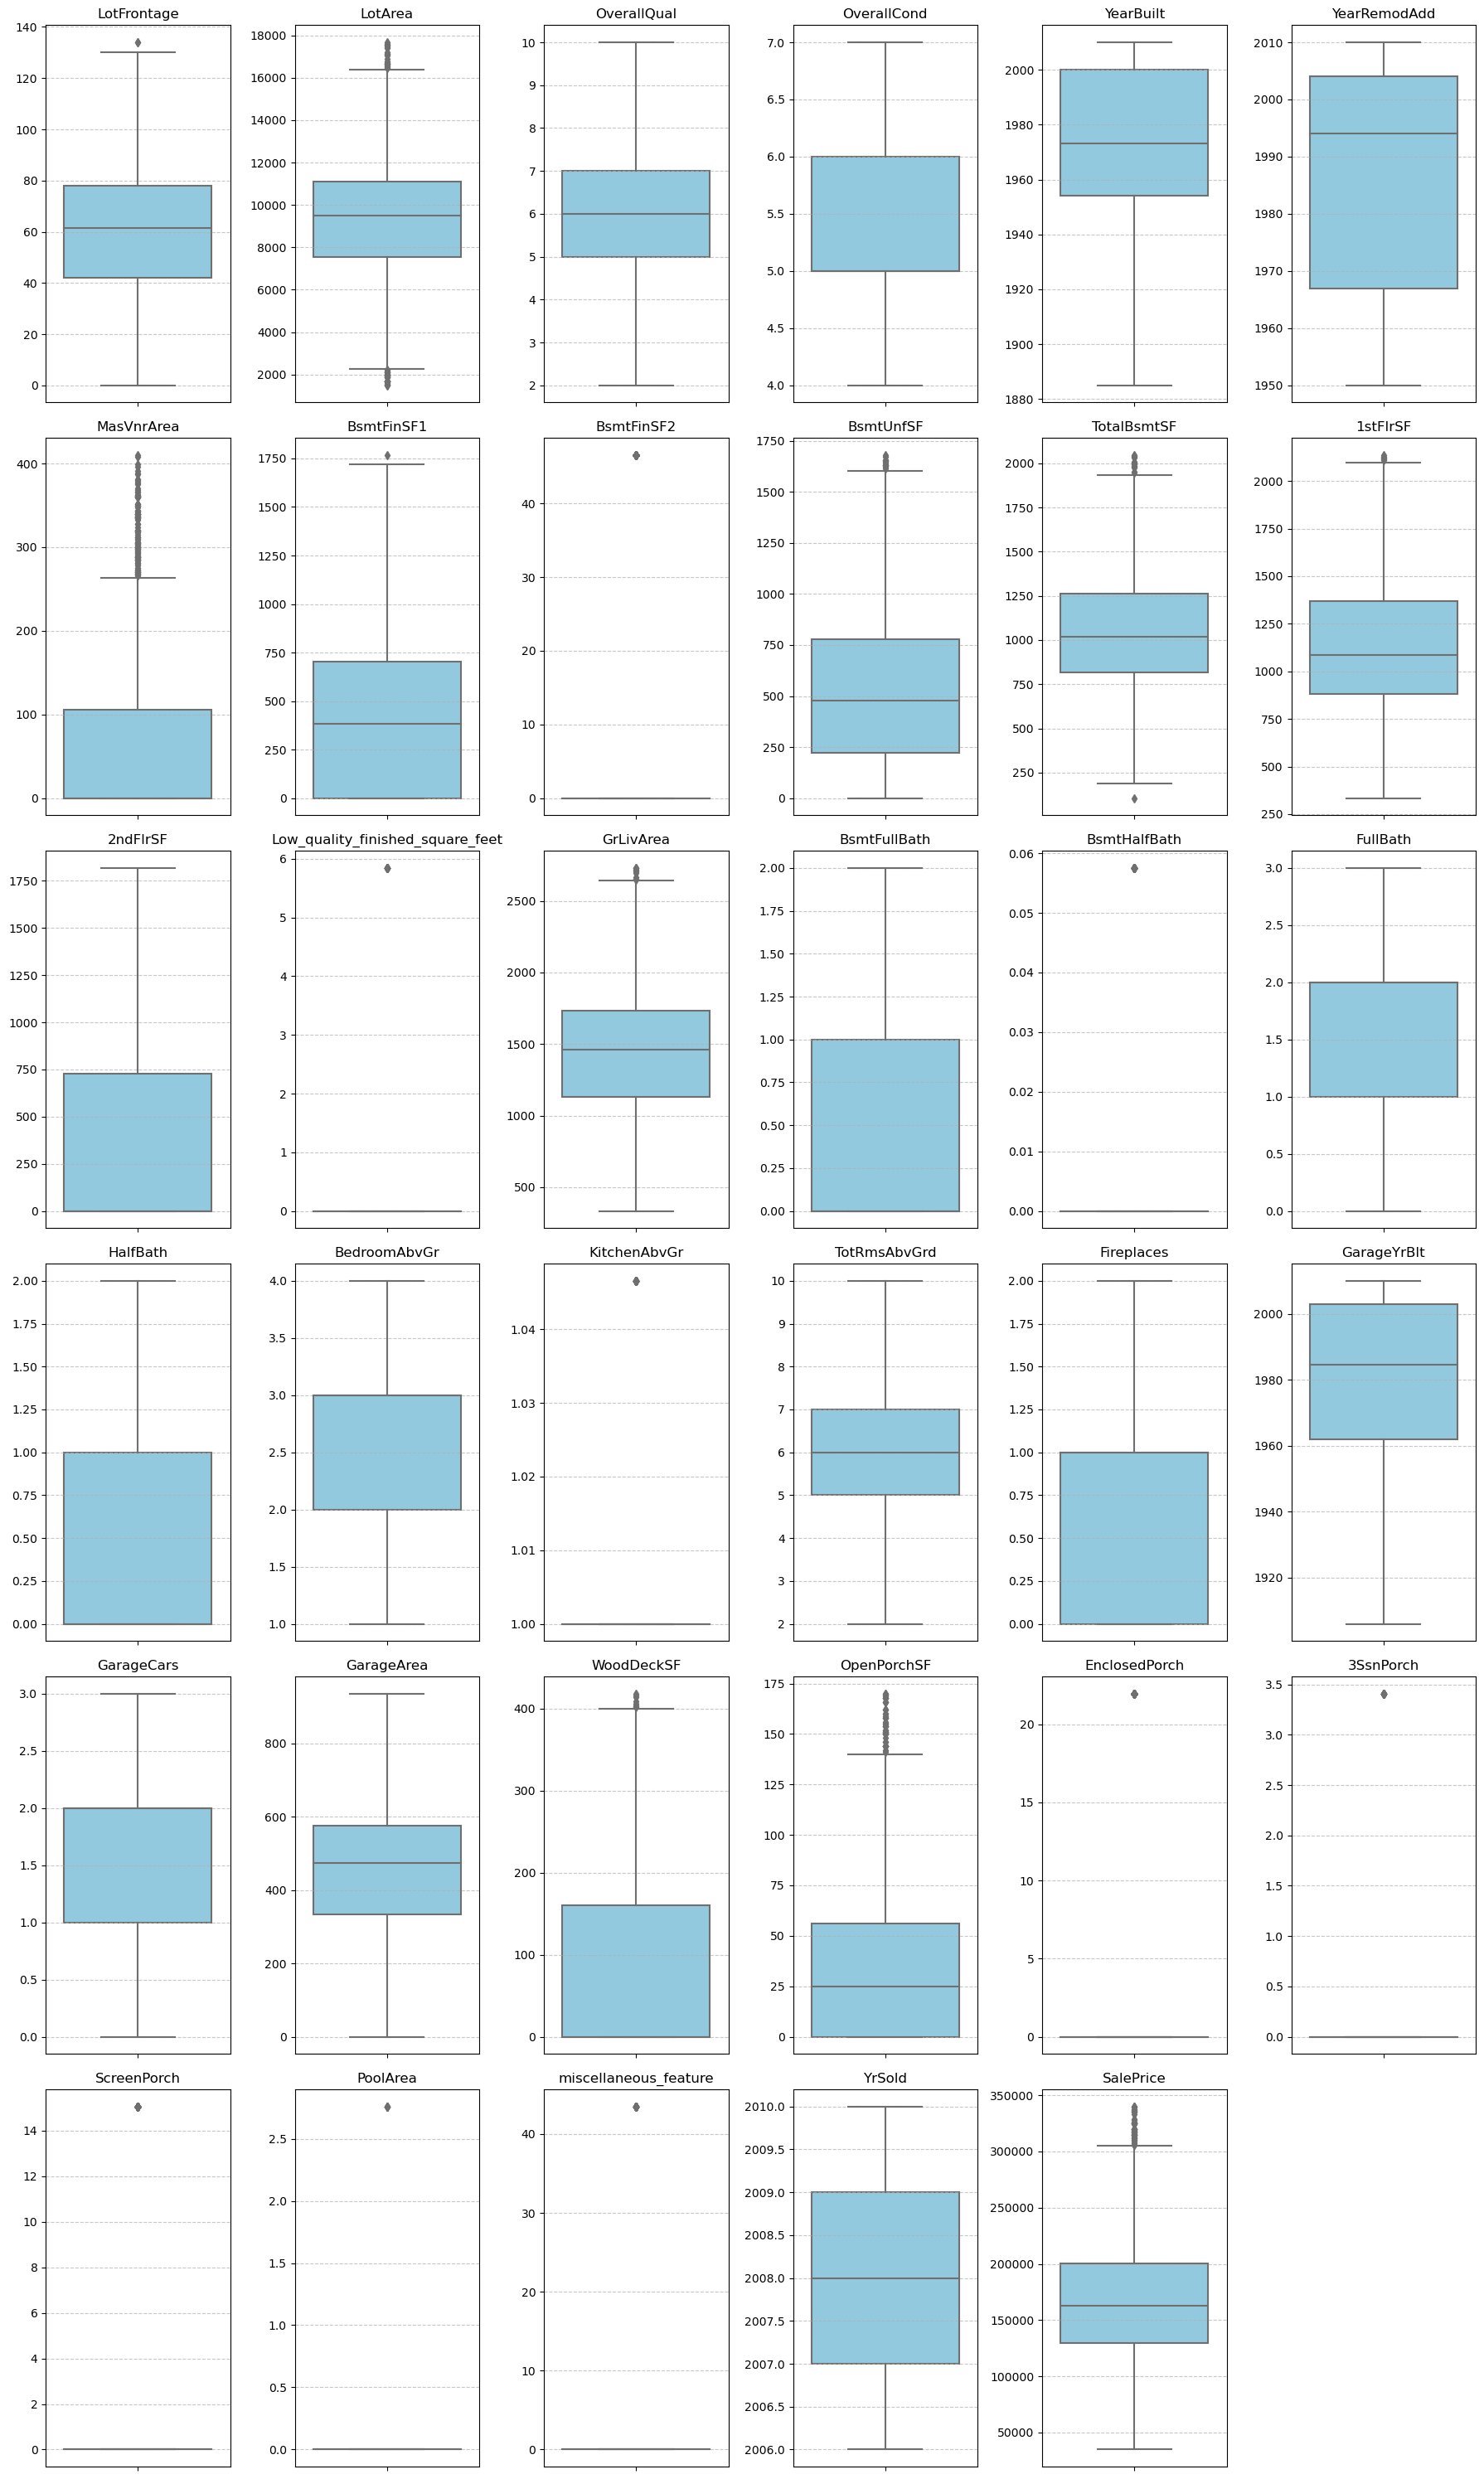

In [1489]:
# Select numerical columns
numerical = housing_data.select_dtypes(include=['float64', 'int64']).columns

if len(numerical) > 0:
    # Define number of rows and columns for subplots
    n_cols = 6
    n_rows = -(-len(numerical) // n_cols)  # Ceiling division for rows
    
    plt.figure(figsize=(18, 5 * n_rows))
    
    for i, col in enumerate(numerical, 1):
        plt.subplot(n_rows, n_cols, i)
        sns.boxplot(y=housing_data[col], color='skyblue')
        plt.title(col, fontsize=12)
        plt.ylabel('')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()
else:
    print("No numerical columns found in the DataFrame.")


In [1490]:
lower_limit_iqr, upper_limit_iqr = iqr_technique(housing_data['LotFrontage'])
housing_data['LotFrontage'] = np.where(housing_data['LotFrontage'] > upper_limit_iqr, 
                                     upper_limit_iqr, 
                                     np.where(housing_data['LotFrontage'] < lower_limit_iqr, 
                                              lower_limit_iqr, 
                                              housing_data['LotFrontage']))


In [1491]:
lower_limit_iqr, upper_limit_iqr = iqr_technique(housing_data['LotArea'])
housing_data['LotArea'] = np.where(housing_data['LotArea'] > upper_limit_iqr, 
                                     upper_limit_iqr, 
                                     np.where(housing_data['LotArea'] < lower_limit_iqr, 
                                              lower_limit_iqr, 
                                              housing_data['LotArea']))


In [1492]:
lower_limit_iqr, upper_limit_iqr = iqr_technique(housing_data['MasVnrArea'])
housing_data['MasVnrArea'] = np.where(housing_data['MasVnrArea'] > upper_limit_iqr, 
                                     upper_limit_iqr, 
                                     np.where(housing_data['MasVnrArea'] < lower_limit_iqr, 
                                              lower_limit_iqr, 
                                              housing_data['MasVnrArea']))


In [1493]:
lower_limit_iqr, upper_limit_iqr = iqr_technique(housing_data['BsmtFinSF1'])
housing_data['BsmtFinSF1'] = np.where(housing_data['BsmtFinSF1'] > upper_limit_iqr, 
                                     upper_limit_iqr, 
                                     np.where(housing_data['BsmtFinSF1'] < lower_limit_iqr, 
                                              lower_limit_iqr, 
                                              housing_data['BsmtFinSF1']))


In [1494]:
lower_limit_iqr, upper_limit_iqr = iqr_technique(housing_data['BsmtUnfSF'])
housing_data['BsmtUnfSF'] = np.where(housing_data['BsmtUnfSF'] > upper_limit_iqr, 
                                     upper_limit_iqr, 
                                     np.where(housing_data['BsmtUnfSF'] < lower_limit_iqr, 
                                              lower_limit_iqr, 
                                              housing_data['BsmtUnfSF']))


In [1495]:
lower_limit_iqr, upper_limit_iqr = iqr_technique(housing_data['TotalBsmtSF'])
housing_data['TotalBsmtSF'] = np.where(housing_data['TotalBsmtSF'] > upper_limit_iqr, 
                                     upper_limit_iqr, 
                                     np.where(housing_data['TotalBsmtSF'] < lower_limit_iqr, 
                                              lower_limit_iqr, 
                                              housing_data['TotalBsmtSF']))


In [1496]:
lower_limit_iqr, upper_limit_iqr = iqr_technique(housing_data['1stFlrSF'])
housing_data['1stFlrSF'] = np.where(housing_data['1stFlrSF'] > upper_limit_iqr, 
                                     upper_limit_iqr, 
                                     np.where(housing_data['1stFlrSF'] < lower_limit_iqr, 
                                              lower_limit_iqr, 
                                              housing_data['1stFlrSF']))


In [1497]:
lower_limit_iqr, upper_limit_iqr = iqr_technique(housing_data['LotFrontage'])
housing_data['LotFrontage'] = np.where(housing_data['LotFrontage'] > upper_limit_iqr, 
                                     upper_limit_iqr, 
                                     np.where(housing_data['LotFrontage'] < lower_limit_iqr, 
                                              lower_limit_iqr, 
                                              housing_data['LotFrontage']))


In [1498]:
lower_limit_iqr, upper_limit_iqr = iqr_technique(housing_data['WoodDeckSF'])
housing_data['WoodDeckSF'] = np.where(housing_data['LotFrontage'] > upper_limit_iqr, 
                                     upper_limit_iqr, 
                                     np.where(housing_data['WoodDeckSF'] < lower_limit_iqr, 
                                              lower_limit_iqr, 
                                              housing_data['WoodDeckSF']))


In [1499]:
lower_limit_iqr, upper_limit_iqr = iqr_technique(housing_data['OpenPorchSF'])
housing_data['OpenPorchSF'] = np.where(housing_data['OpenPorchSF'] > upper_limit_iqr, 
                                     upper_limit_iqr, 
                                     np.where(housing_data['OpenPorchSF'] < lower_limit_iqr, 
                                              lower_limit_iqr, 
                                              housing_data['OpenPorchSF']))


In [1500]:
lower_limit_iqr, upper_limit_iqr = iqr_technique(housing_data['GrLivArea'])
housing_data['GrLivArea'] = np.where(housing_data['GrLivArea'] > upper_limit_iqr, 
                                     upper_limit_iqr, 
                                     np.where(housing_data['GrLivArea'] < lower_limit_iqr, 
                                              lower_limit_iqr, 
                                              housing_data['GrLivArea']))


In [1501]:
lower_limit_iqr, upper_limit_iqr = iqr_technique(housing_data['SalePrice'])
housing_data['SalePrice'] = np.where(housing_data['SalePrice'] > upper_limit_iqr, 
                                     upper_limit_iqr, 
                                     np.where(housing_data['SalePrice'] < lower_limit_iqr, 
                                              lower_limit_iqr, 
                                              housing_data['SalePrice']))


In [1502]:
# Remove spaces in column names
housing_data.columns = housing_data.columns.str.strip()

# Check if PricePerSqFt exists
if 'PricePerSqFt' in housing_data.columns:
    lower_limit = 31.92867451213431
    upper_limit = 106.62368107360518
    mean_value = housing_data['PricePerSqFt'].mean()

    # Replace outliers
    housing_data['PricePerSqFt'] = np.where((housing_data['PricePerSqFt'] < lower_limit) | 
                                            (housing_data['PricePerSqFt'] > upper_limit), 
                                            mean_value, 
                                            housing_data['PricePerSqFt'])
else:
    print("Error: Column 'PricePerSqFt' not found!")


Error: Column 'PricePerSqFt' not found!


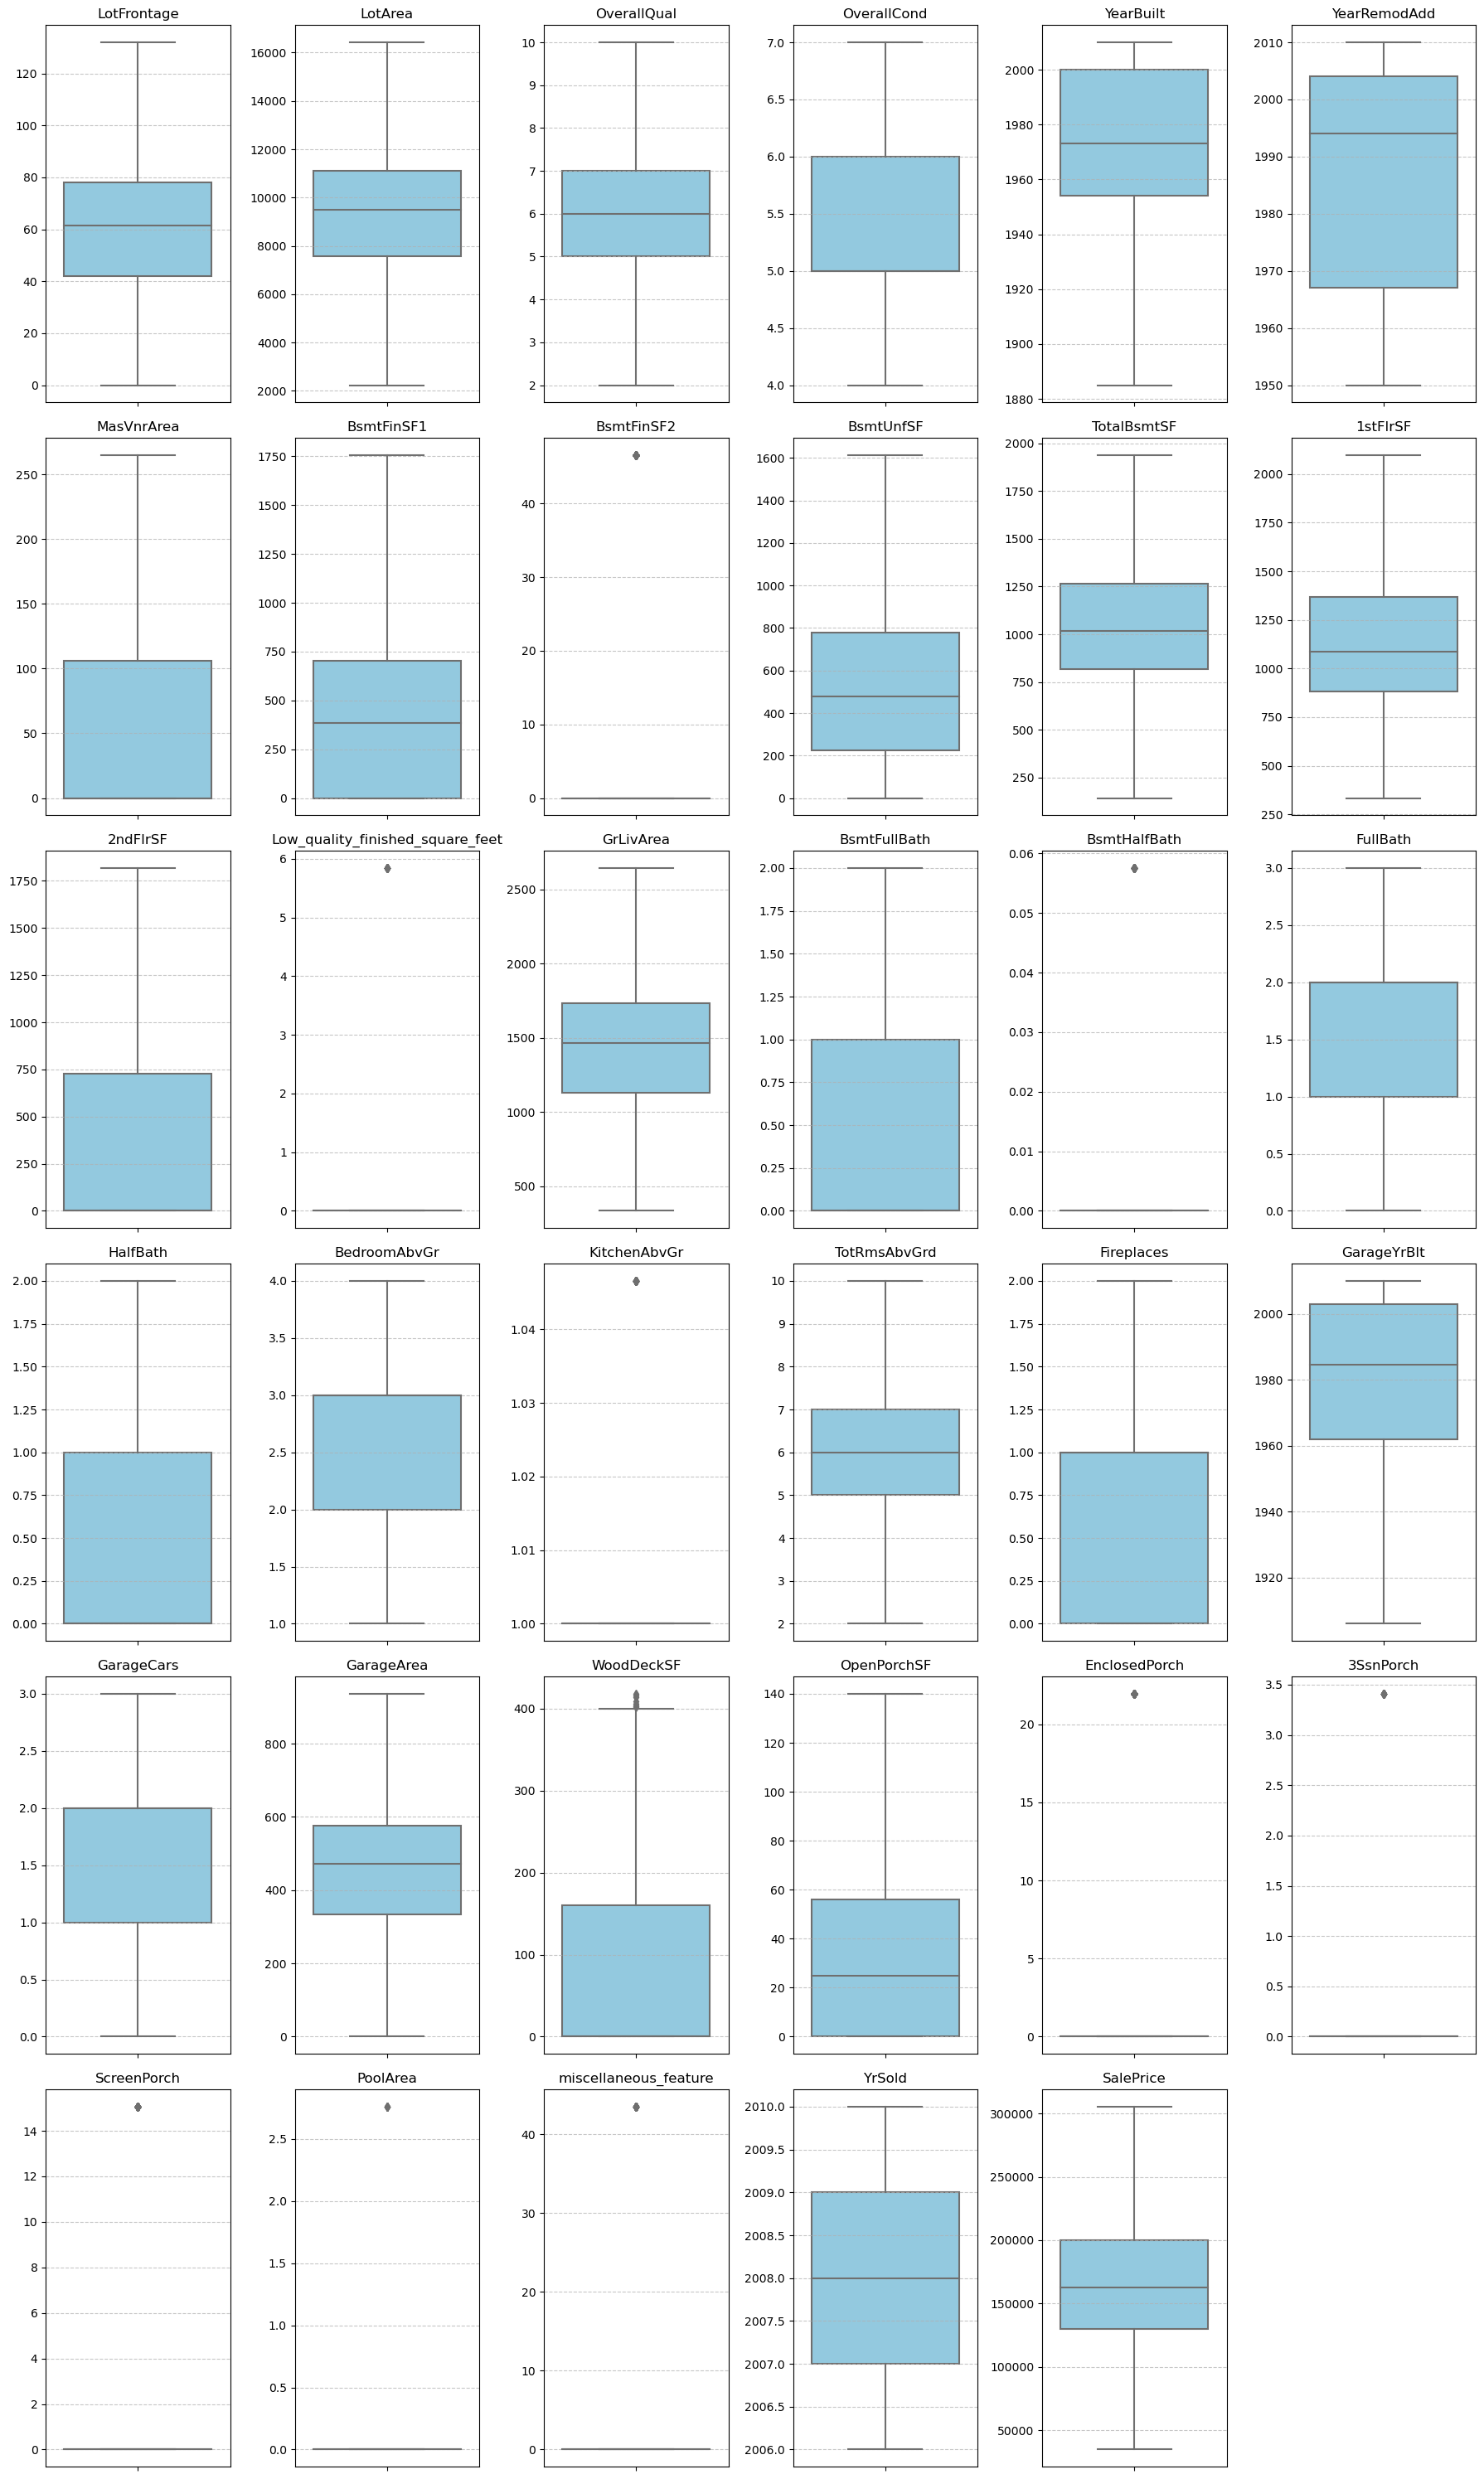

In [1503]:
# Select numerical columns
numerical = housing_data.select_dtypes(include=['float64', 'int64']).columns

if len(numerical) > 0:
    # Define number of rows and columns for subplots
    n_cols = 6
    n_rows = -(-len(numerical) // n_cols)  # Ceiling division for rows
    
    plt.figure(figsize=(18, 5 * n_rows))
    
    for i, col in enumerate(numerical, 1):
        plt.subplot(n_rows, n_cols, i)
        sns.boxplot(y=housing_data[col], color='skyblue')
        plt.title(col, fontsize=12)
        plt.ylabel('')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()
else:
    print("No numerical columns found in the DataFrame.")


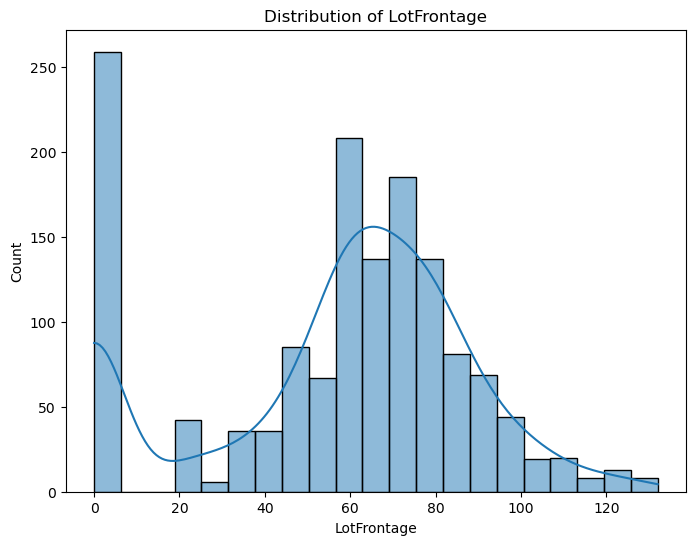

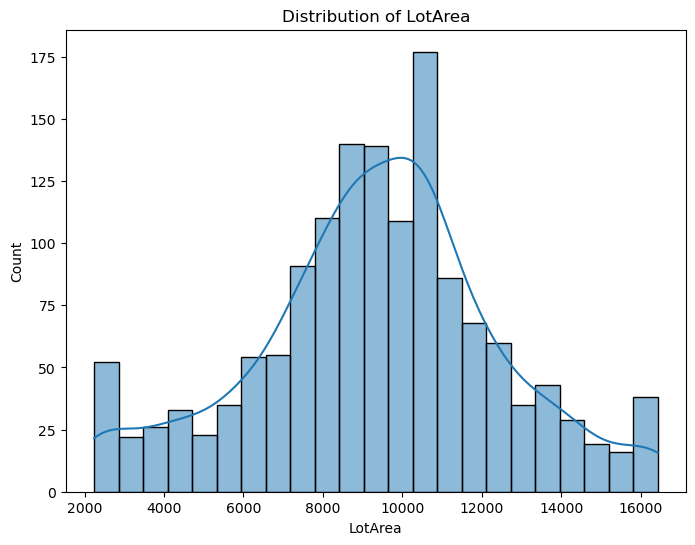

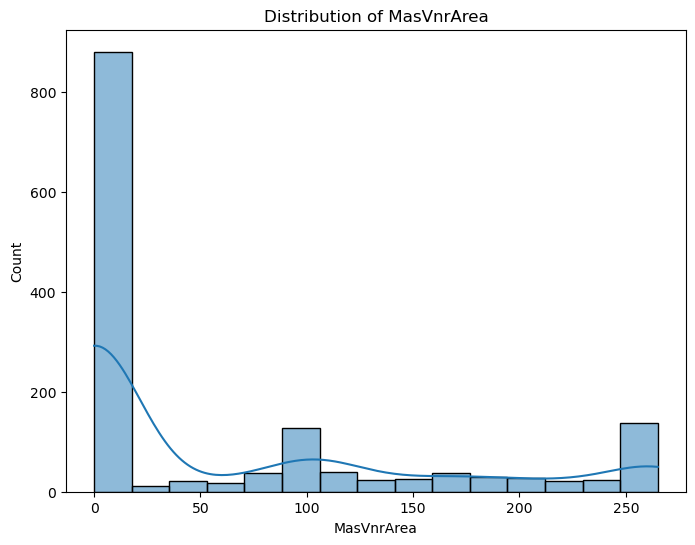

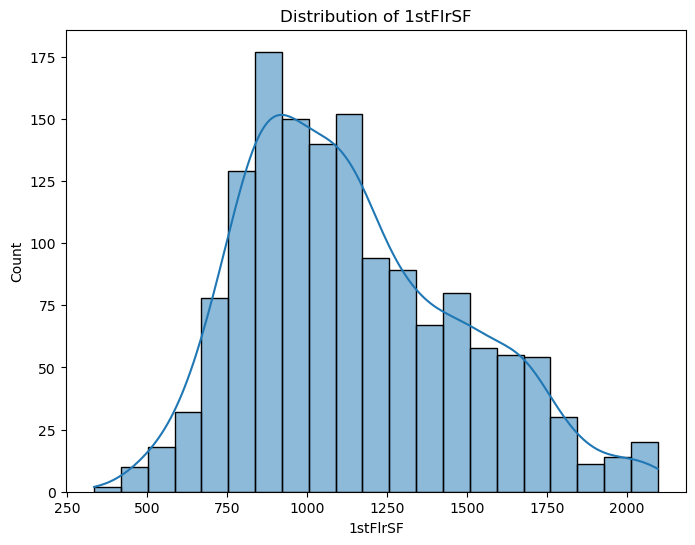

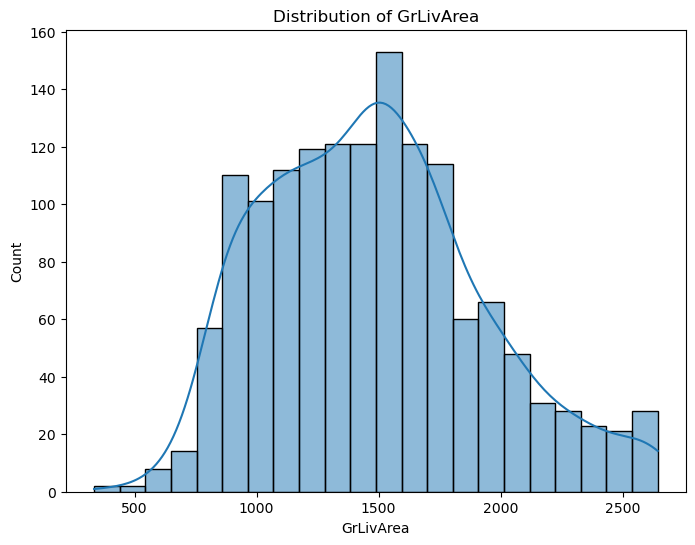

In [1504]:
numeric_vars = ['LotFrontage', 'LotArea', 'MasVnrArea', '1stFlrSF', 'GrLivArea']
for var in numeric_vars:
    plt.figure(figsize=(8, 6))
    sns.histplot(data=housing_data, x=var, kde=True)
    plt.title(f'Distribution of {var}')
    plt.show()

In [1505]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_vars = ['Identifies_the_type_of_dwelling', 'Street', 'Lot_configuration', 'LotShape']

for var in categorical_vars:
    if var in housing_data.columns:  # Ensure column exists
        plt.figure(figsize=(8, 6))
        sns.countplot(data=housing_data, x=var, palette="viridis")  # Add color
        plt.title(f'Count of {var}')
        plt.xticks(rotation=45)  # Rotate labels for readability
        plt.show()
    else:
        print(f"Warning: Column '{var}' not found in DataFrame!")


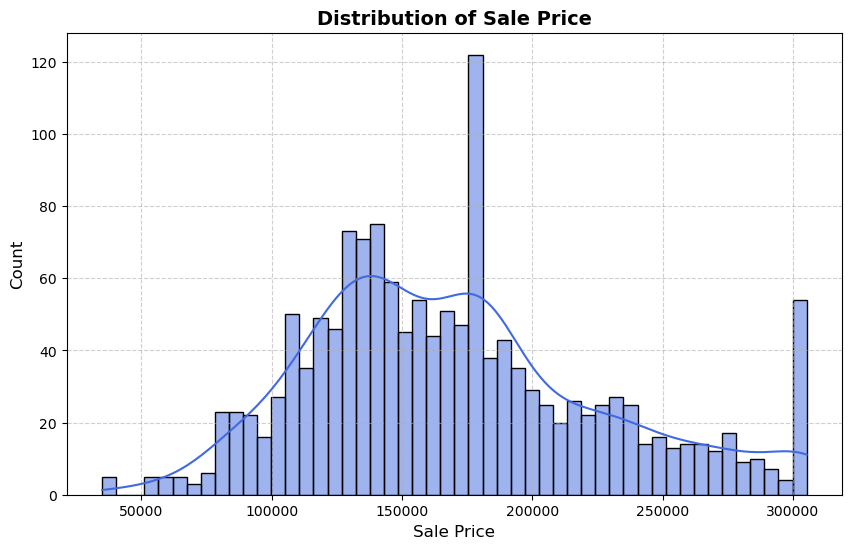

In [1506]:
plt.figure(figsize=(10, 6))  # Slightly larger for better visibility
sns.histplot(data=housing_data, x='SalePrice', kde=True, bins=50, color='royalblue')
plt.title('Distribution of Sale Price', fontsize=14, fontweight='bold')
plt.xlabel('Sale Price', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)  # Add grid for readability
plt.show()


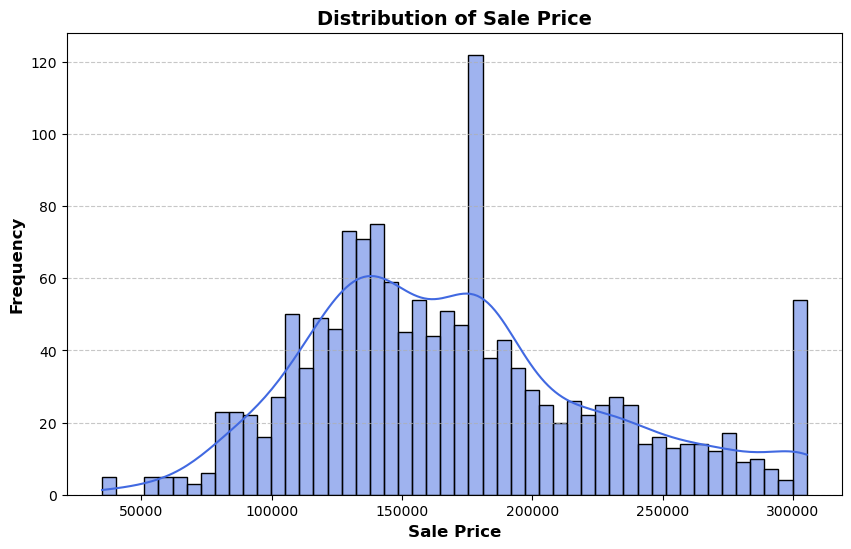

In [1507]:
plt.figure(figsize=(10, 6))  # Keep size for readability
sns.histplot(data=housing_data, x='SalePrice', bins=50, kde=True, color='royalblue') 

# Formatting labels and title
plt.xlabel('Sale Price', fontsize=12, fontweight='bold')
plt.ylabel('Frequency', fontsize=12, fontweight='bold')
plt.title('Distribution of Sale Price', fontsize=14, fontweight='bold')

# Grid for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()


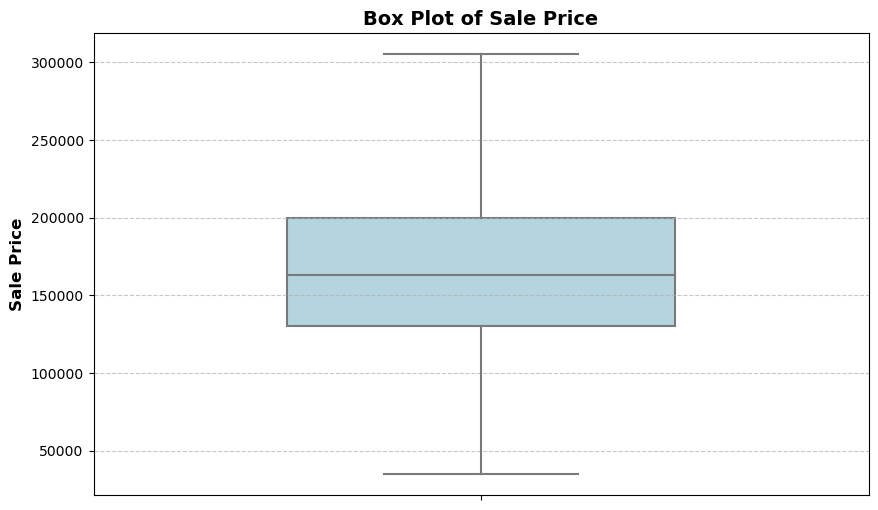

In [1508]:
plt.figure(figsize=(10, 6))  # Maintain size for visibility
sns.boxplot(data=housing_data, y='SalePrice', color='lightblue', width=0.5, fliersize=4)

# Formatting labels and title
plt.ylabel('Sale Price', fontsize=12, fontweight='bold')
plt.title('Box Plot of Sale Price', fontsize=14, fontweight='bold')

# Grid for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()


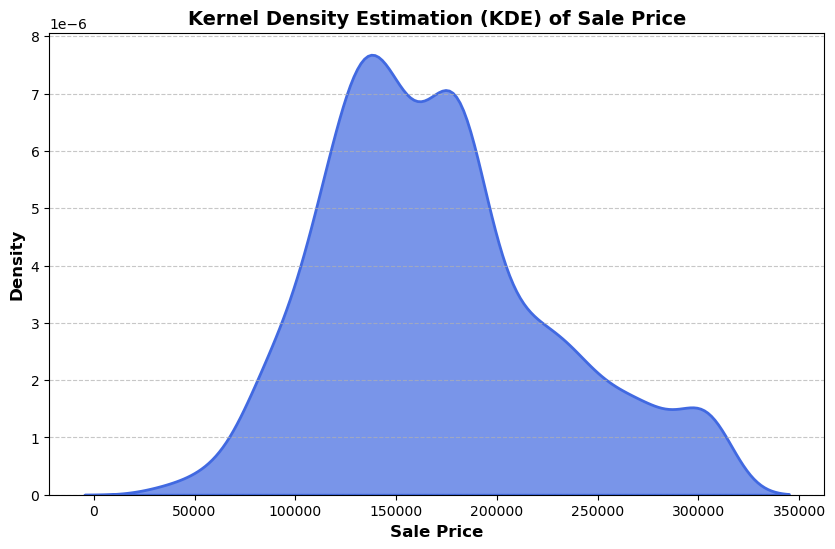

In [1509]:
plt.figure(figsize=(10, 6))  # Set figure size
sns.kdeplot(data=housing_data['SalePrice'], fill=True, color='royalblue', alpha=0.7, linewidth=2)

# Formatting labels and title
plt.xlabel('Sale Price', fontsize=12, fontweight='bold')
plt.ylabel('Density', fontsize=12, fontweight='bold')
plt.title('Kernel Density Estimation (KDE) of Sale Price', fontsize=14, fontweight='bold')

# Grid for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()


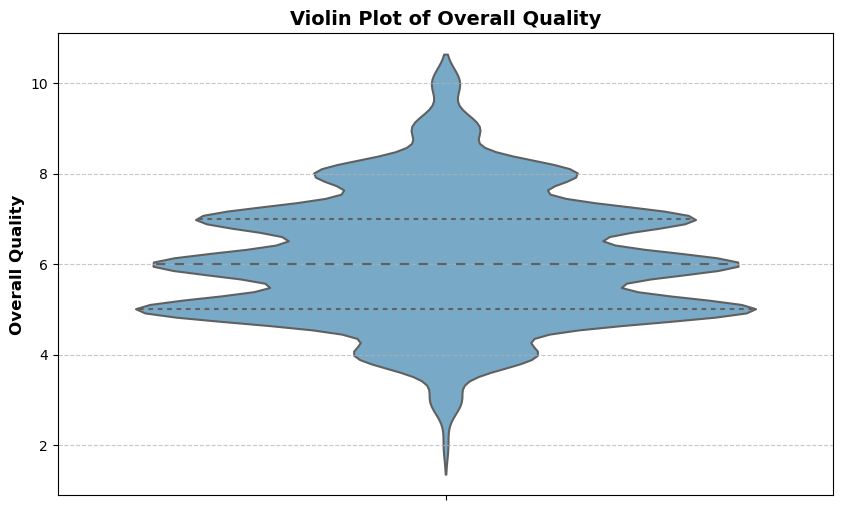

In [1510]:
plt.figure(figsize=(10, 6))  # Maintain a large figure size
sns.violinplot(data=housing_data, y='OverallQual', inner='quartile', palette='Blues')

# Formatting labels and title
plt.ylabel('Overall Quality', fontsize=12, fontweight='bold')
plt.title('Violin Plot of Overall Quality', fontsize=14, fontweight='bold')

# Grid for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()


In [1511]:
housing_data.head()

,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,miscellaneous_feature,YrSold,SalePrice
0,65.0,8450.0,7.0,5.000000,2003.0,2003.0,196.0,706.0,0.0,150.0,...,548.0,0.0,61.0,0.00000,0.0,0.0,0.0,0.0,2008.0,208500.0
1,80.0,9600.0,6.0,5.575342,1976.0,1976.0,0.0,978.0,0.0,284.0,...,460.0,298.0,0.0,0.00000,0.0,0.0,0.0,0.0,2007.0,181500.0
2,68.0,11250.0,7.0,5.000000,2001.0,2002.0,162.0,486.0,0.0,434.0,...,608.0,0.0,42.0,0.00000,0.0,0.0,0.0,0.0,2008.0,223500.0
3,60.0,9550.0,7.0,5.000000,1915.0,1970.0,0.0,216.0,0.0,540.0,...,642.0,0.0,35.0,21.95411,0.0,0.0,0.0,0.0,2006.0,140000.0
4,84.0,14260.0,8.0,5.000000,2000.0,2000.0,265.0,655.0,0.0,490.0,...,836.0,192.0,84.0,0.00000,0.0,0.0,0.0,0.0,2008.0,250000.0


In [1512]:
exclude_housing_data=housing_data.select_dtypes(exclude=['object'])

In [1513]:
exclude_housing_data

,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,miscellaneous_feature,YrSold,SalePrice
0,65.0,8450.0,7.0,5.000000,2003.0,2003.0,196.0,706.0,0.000000,150.0,...,548.0,0.000000,61.0,0.00000,0.0,0.0,0.0,0.000000,2008.0,208500.0
1,80.0,9600.0,6.0,5.575342,1976.0,1976.0,0.0,978.0,0.000000,284.0,...,460.0,298.000000,0.0,0.00000,0.0,0.0,0.0,0.000000,2007.0,181500.0
2,68.0,11250.0,7.0,5.000000,2001.0,2002.0,162.0,486.0,0.000000,434.0,...,608.0,0.000000,42.0,0.00000,0.0,0.0,0.0,0.000000,2008.0,223500.0
3,60.0,9550.0,7.0,5.000000,1915.0,1970.0,0.0,216.0,0.000000,540.0,...,642.0,0.000000,35.0,21.95411,0.0,0.0,0.0,0.000000,2006.0,140000.0
4,84.0,14260.0,8.0,5.000000,2000.0,2000.0,265.0,655.0,0.000000,490.0,...,836.0,192.000000,84.0,0.00000,0.0,0.0,0.0,0.000000,2008.0,250000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,62.0,7917.0,6.0,5.000000,1999.0,2000.0,0.0,0.0,0.000000,953.0,...,460.0,0.000000,40.0,0.00000,0.0,0.0,0.0,0.000000,2007.0,175000.0
1456,85.0,13175.0,6.0,6.000000,1978.0,1988.0,119.0,790.0,46.549315,589.0,...,500.0,349.000000,0.0,0.00000,0.0,0.0,0.0,0.000000,2010.0,210000.0
1457,66.0,9042.0,7.0,5.575342,1941.0,2006.0,0.0,275.0,0.000000,877.0,...,252.0,0.000000,60.0,0.00000,0.0,0.0,0.0,43.489041,2010.0,266500.0
1458,68.0,9717.0,5.0,6.000000,1950.0,1996.0,0.0,49.0,46.549315,0.0,...,240.0,366.000000,0.0,21.95411,0.0,0.0,0.0,0.000000,2010.0,142125.0


In [1514]:
exclude_housing_data.columns

Index(['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt',
       'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
       'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'Low_quality_finished_square_feet', 'GrLivArea', 'BsmtFullBath',
       'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr',
       'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea',
       'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch',
       'ScreenPorch', 'PoolArea', 'miscellaneous_feature', 'YrSold',
       'SalePrice'],
      dtype='object')

In [1515]:
corr_matrix = exclude_housing_data.corr()

In [1516]:
corr_matrix

,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,miscellaneous_feature,YrSold,SalePrice
LotFrontage,1.000000,0.252492,0.157877,-0.052545,0.044972,0.068039,0.067804,-0.009754,-0.037623,0.166081,...,0.180758,0.018839,0.084692,0.001660,0.019213,0.029874,0.003877,-0.032880,-0.020426,0.124670
LotArea,0.252492,1.000000,0.235955,-0.020774,0.103626,0.072399,0.124036,0.180457,0.055898,0.057787,...,0.324228,0.168183,0.150428,-0.057523,0.039742,0.080692,0.058803,0.049382,-0.021967,0.386049
OverallQual,0.157877,0.235955,1.000000,-0.216323,0.590075,0.547279,0.340837,0.200454,-0.108031,0.244760,...,0.548566,0.256550,0.387304,-0.168995,0.025364,0.043770,0.074252,-0.090473,-0.026898,0.724710
OverallCond,-0.052545,-0.020774,-0.216323,1.000000,-0.400052,-0.100501,-0.151322,-0.041242,0.105716,-0.133340,...,-0.206059,-0.055526,-0.162962,0.118320,0.035327,0.091083,-0.003178,0.088504,0.046591,-0.152765
YearBuilt,0.044972,0.103626,0.590075,-0.400052,1.000000,0.609084,0.334128,0.238585,-0.076757,0.115773,...,0.486224,0.268218,0.323463,-0.446862,0.027921,-0.069438,0.005046,-0.082203,-0.010109,0.574094
YearRemodAdd,0.068039,0.072399,0.547279,-0.100501,0.609084,1.000000,0.159813,0.119177,-0.104958,0.147431,...,0.371908,0.251125,0.312906,-0.231304,0.053563,-0.041039,0.009580,-0.080048,0.035743,0.541550
MasVnrArea,0.067804,0.124036,0.340837,-0.151322,0.334128,0.159813,1.000000,0.212033,-0.051235,0.059509,...,0.322020,0.150966,0.153502,-0.153437,0.039675,0.028731,-0.006837,-0.054788,0.000966,0.339531
BsmtFinSF1,-0.009754,0.180457,0.200454,-0.041242,0.238585,0.119177,0.212033,1.000000,0.010265,-0.521318,...,0.258189,0.198347,0.076772,-0.147816,0.039089,0.081602,0.020238,-0.001723,0.015445,0.293346
BsmtFinSF2,-0.037623,0.055898,-0.108031,0.105716,-0.076757,-0.104958,-0.051235,0.010265,1.000000,-0.239042,...,0.000352,0.075157,-0.081733,0.038223,-0.012612,0.053565,0.068517,0.035439,0.025561,-0.035900
BsmtUnfSF,0.166081,0.057787,0.244760,-0.133340,0.115773,0.147431,0.059509,-0.521318,-0.239042,1.000000,...,0.134836,-0.041833,0.128582,0.020343,0.017331,-0.038229,-0.036644,-0.049067,-0.045008,0.189482


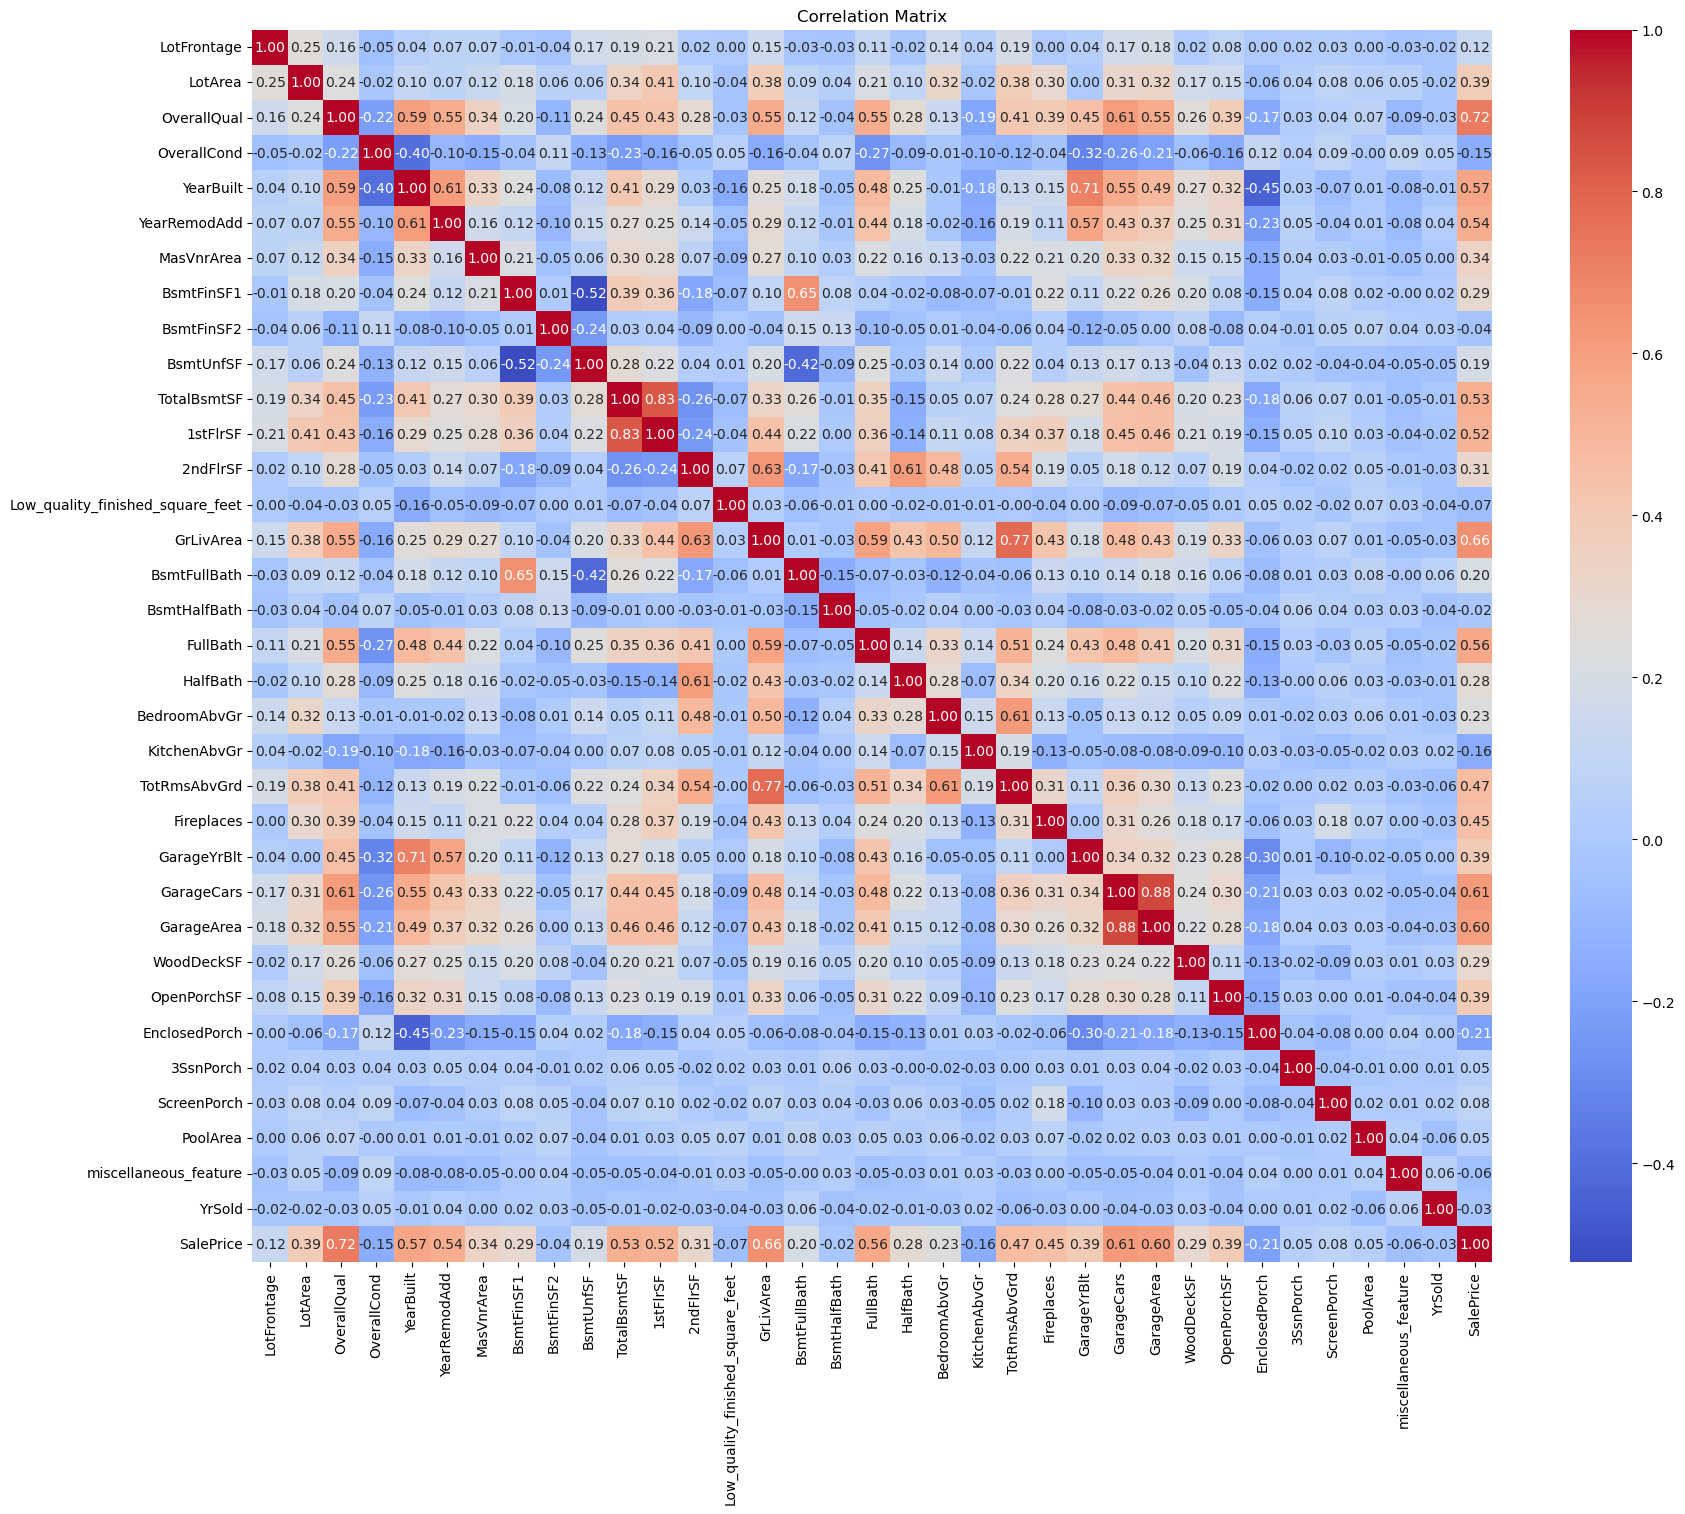

In [1517]:
# Heat-map:
plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

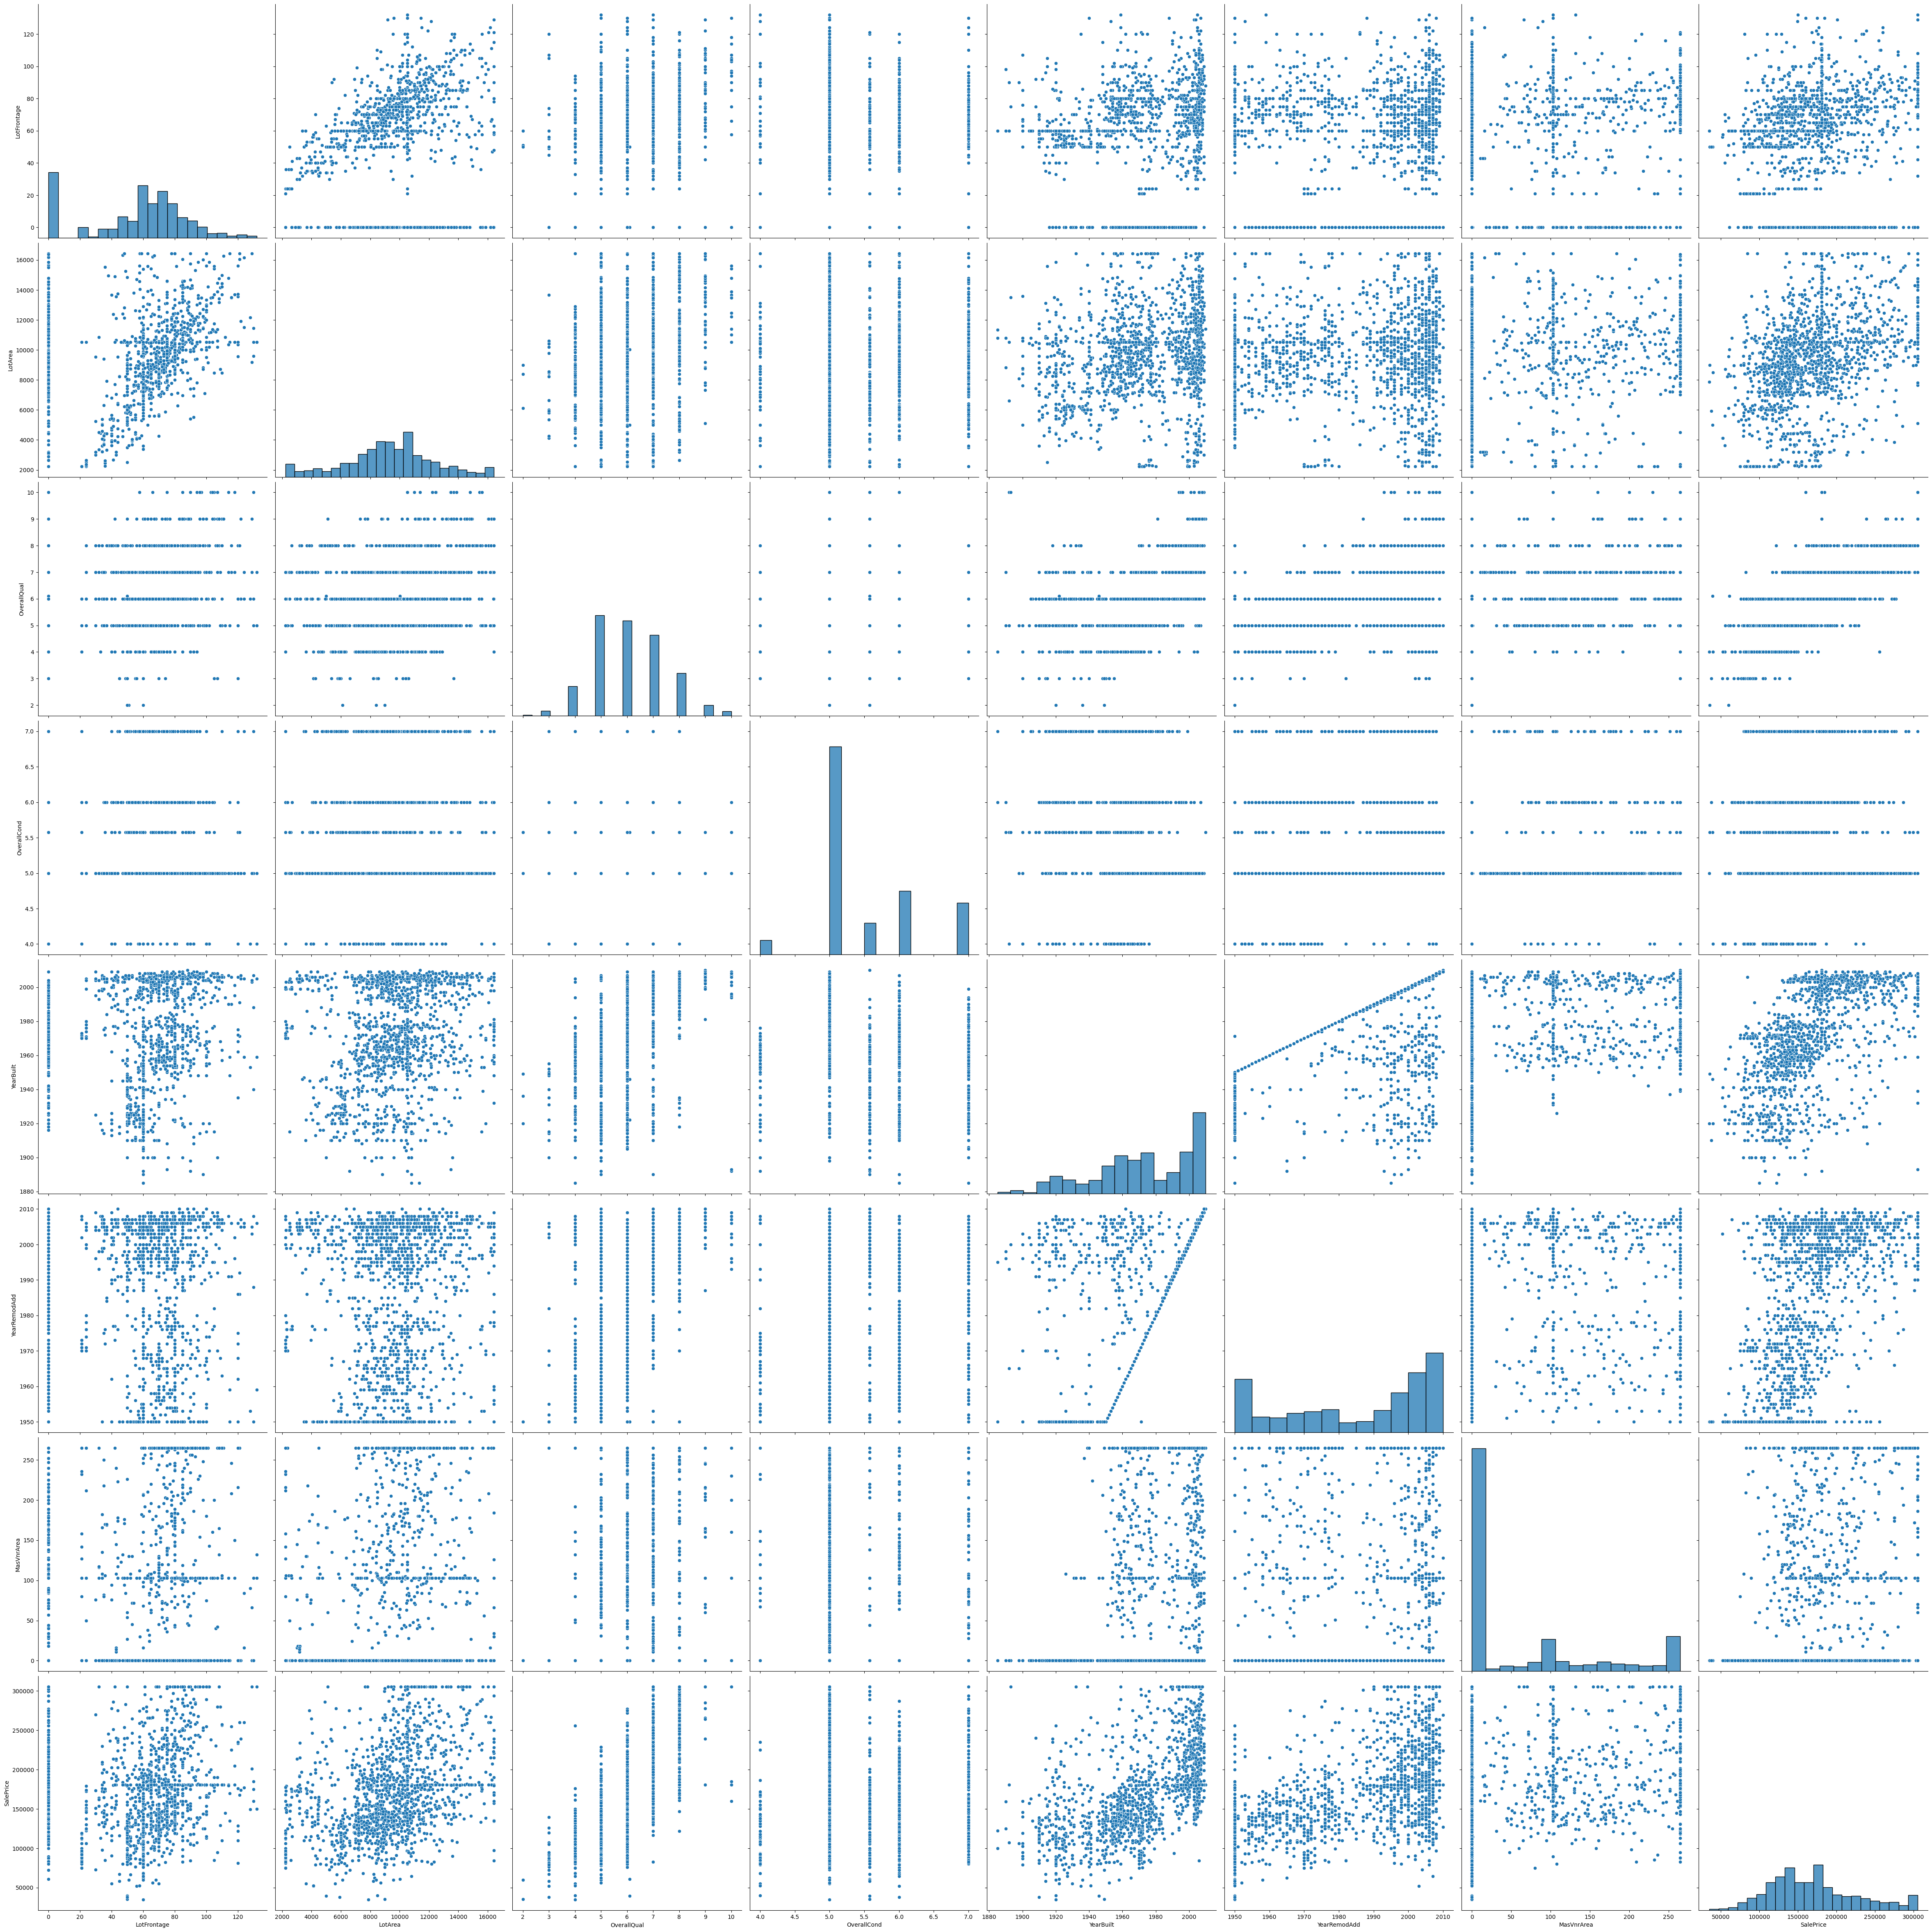

In [ ]:
# Pair-plot:
sns.pairplot(exclude_housing_data[['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt',
       'YearRemodAdd', 'MasVnrArea','SalePrice']], height=6)
plt.show()

In [ ]:
# 5. Feature Engineering:
housing_data.head()

,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,miscellaneous_feature,YrSold,SalePrice
0,65.0,8450.0,7.0,5.000000,2003.0,2003.0,196.0,706.0,0.0,150.0,...,548.0,0.0,61.0,0.00000,0.0,0.0,0.0,0.0,2008.0,208500.0
1,80.0,9600.0,6.0,5.575342,1976.0,1976.0,0.0,978.0,0.0,284.0,...,460.0,298.0,0.0,0.00000,0.0,0.0,0.0,0.0,2007.0,181500.0
2,68.0,11250.0,7.0,5.000000,2001.0,2002.0,162.0,486.0,0.0,434.0,...,608.0,0.0,42.0,0.00000,0.0,0.0,0.0,0.0,2008.0,223500.0
3,60.0,9550.0,7.0,5.000000,1915.0,1970.0,0.0,216.0,0.0,540.0,...,642.0,0.0,35.0,21.95411,0.0,0.0,0.0,0.0,2006.0,140000.0
4,84.0,14260.0,8.0,5.000000,2000.0,2000.0,265.0,655.0,0.0,490.0,...,836.0,192.0,84.0,0.00000,0.0,0.0,0.0,0.0,2008.0,250000.0


In [1520]:
housing_data.columns

Index(['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt',
       'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
       'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'Low_quality_finished_square_feet', 'GrLivArea', 'BsmtFullBath',
       'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr',
       'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea',
       'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch',
       'ScreenPorch', 'PoolArea', 'miscellaneous_feature', 'YrSold',
       'SalePrice'],
      dtype='object')

In [1521]:
housing_data.shape

(1460, 35)

In [1522]:
housing_data['PricePerSqFt'] = housing_data['SalePrice'] / (housing_data['GrLivArea'] + 
                                                            housing_data['TotalBsmtSF'])

In [1523]:
housing_data['PricePerSqFt']

0       81.254871
1       71.909667
2       82.594235
3       56.611403
4       74.783129
          ...    
1455    67.307692
1456    58.091286
1457    76.317297
1458    65.920686
1459    58.718153
Name: PricePerSqFt, Length: 1460, dtype: float64

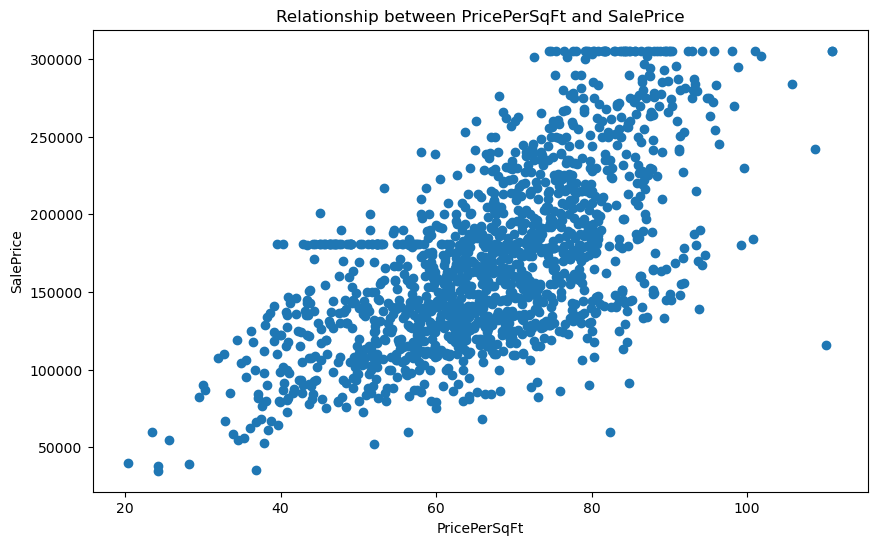

In [1524]:
plt.figure(figsize=(10, 6))
plt.scatter(housing_data['PricePerSqFt'],housing_data['SalePrice'])
plt.xlabel('PricePerSqFt')
plt.ylabel('SalePrice')
plt.title('Relationship between PricePerSqFt and SalePrice')
plt.show()

In [1525]:
housing_data['AgeAtSale'] = housing_data['YrSold'] - housing_data['YearBuilt']

In [1526]:
housing_data['AgeAtSale']

0        5.0
1       31.0
2        7.0
3       91.0
4        8.0
        ... 
1455     8.0
1456    32.0
1457    69.0
1458    60.0
1459    43.0
Name: AgeAtSale, Length: 1460, dtype: float64

In [1527]:
housing_data.drop(columns=['YearBuilt'],inplace=True)

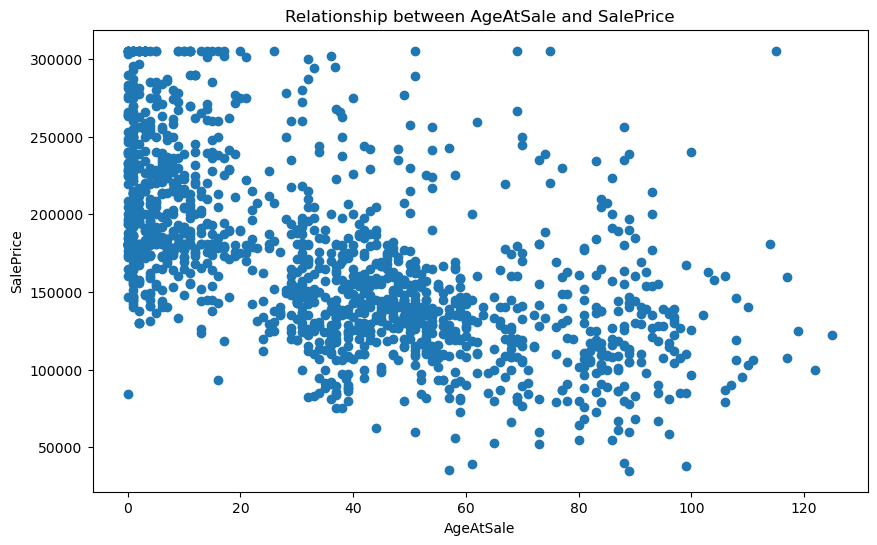

In [1528]:
plt.figure(figsize=(10, 6))
plt.scatter(housing_data['AgeAtSale'],housing_data['SalePrice'])
plt.xlabel('AgeAtSale')
plt.ylabel('SalePrice')
plt.title('Relationship between AgeAtSale and SalePrice')
plt.show()

In [1529]:
housing_data['TotalSqFt'] = housing_data['1stFlrSF'] + housing_data['2ndFlrSF'] + housing_data['TotalBsmtSF']

In [1530]:
housing_data['TotalSqFt']

0       2566.0
1       2524.0
2       2706.0
3       2473.0
4       3343.0
         ...  
1455    2600.0
1456    3615.0
1457    3492.0
1458    2156.0
1459    2512.0
Name: TotalSqFt, Length: 1460, dtype: float64

In [1531]:
housing_data['TotalBathrooms'] = housing_data['FullBath'] + 0.5 * housing_data['HalfBath']
+ housing_data['BsmtFullBath'] + 0.5 * housing_data['BsmtHalfBath']

0       1.000000
1       0.028767
2       1.000000
3       1.000000
4       1.000000
          ...   
1455    0.000000
1456    1.000000
1457    0.000000
1458    1.000000
1459    1.000000
Length: 1460, dtype: float64

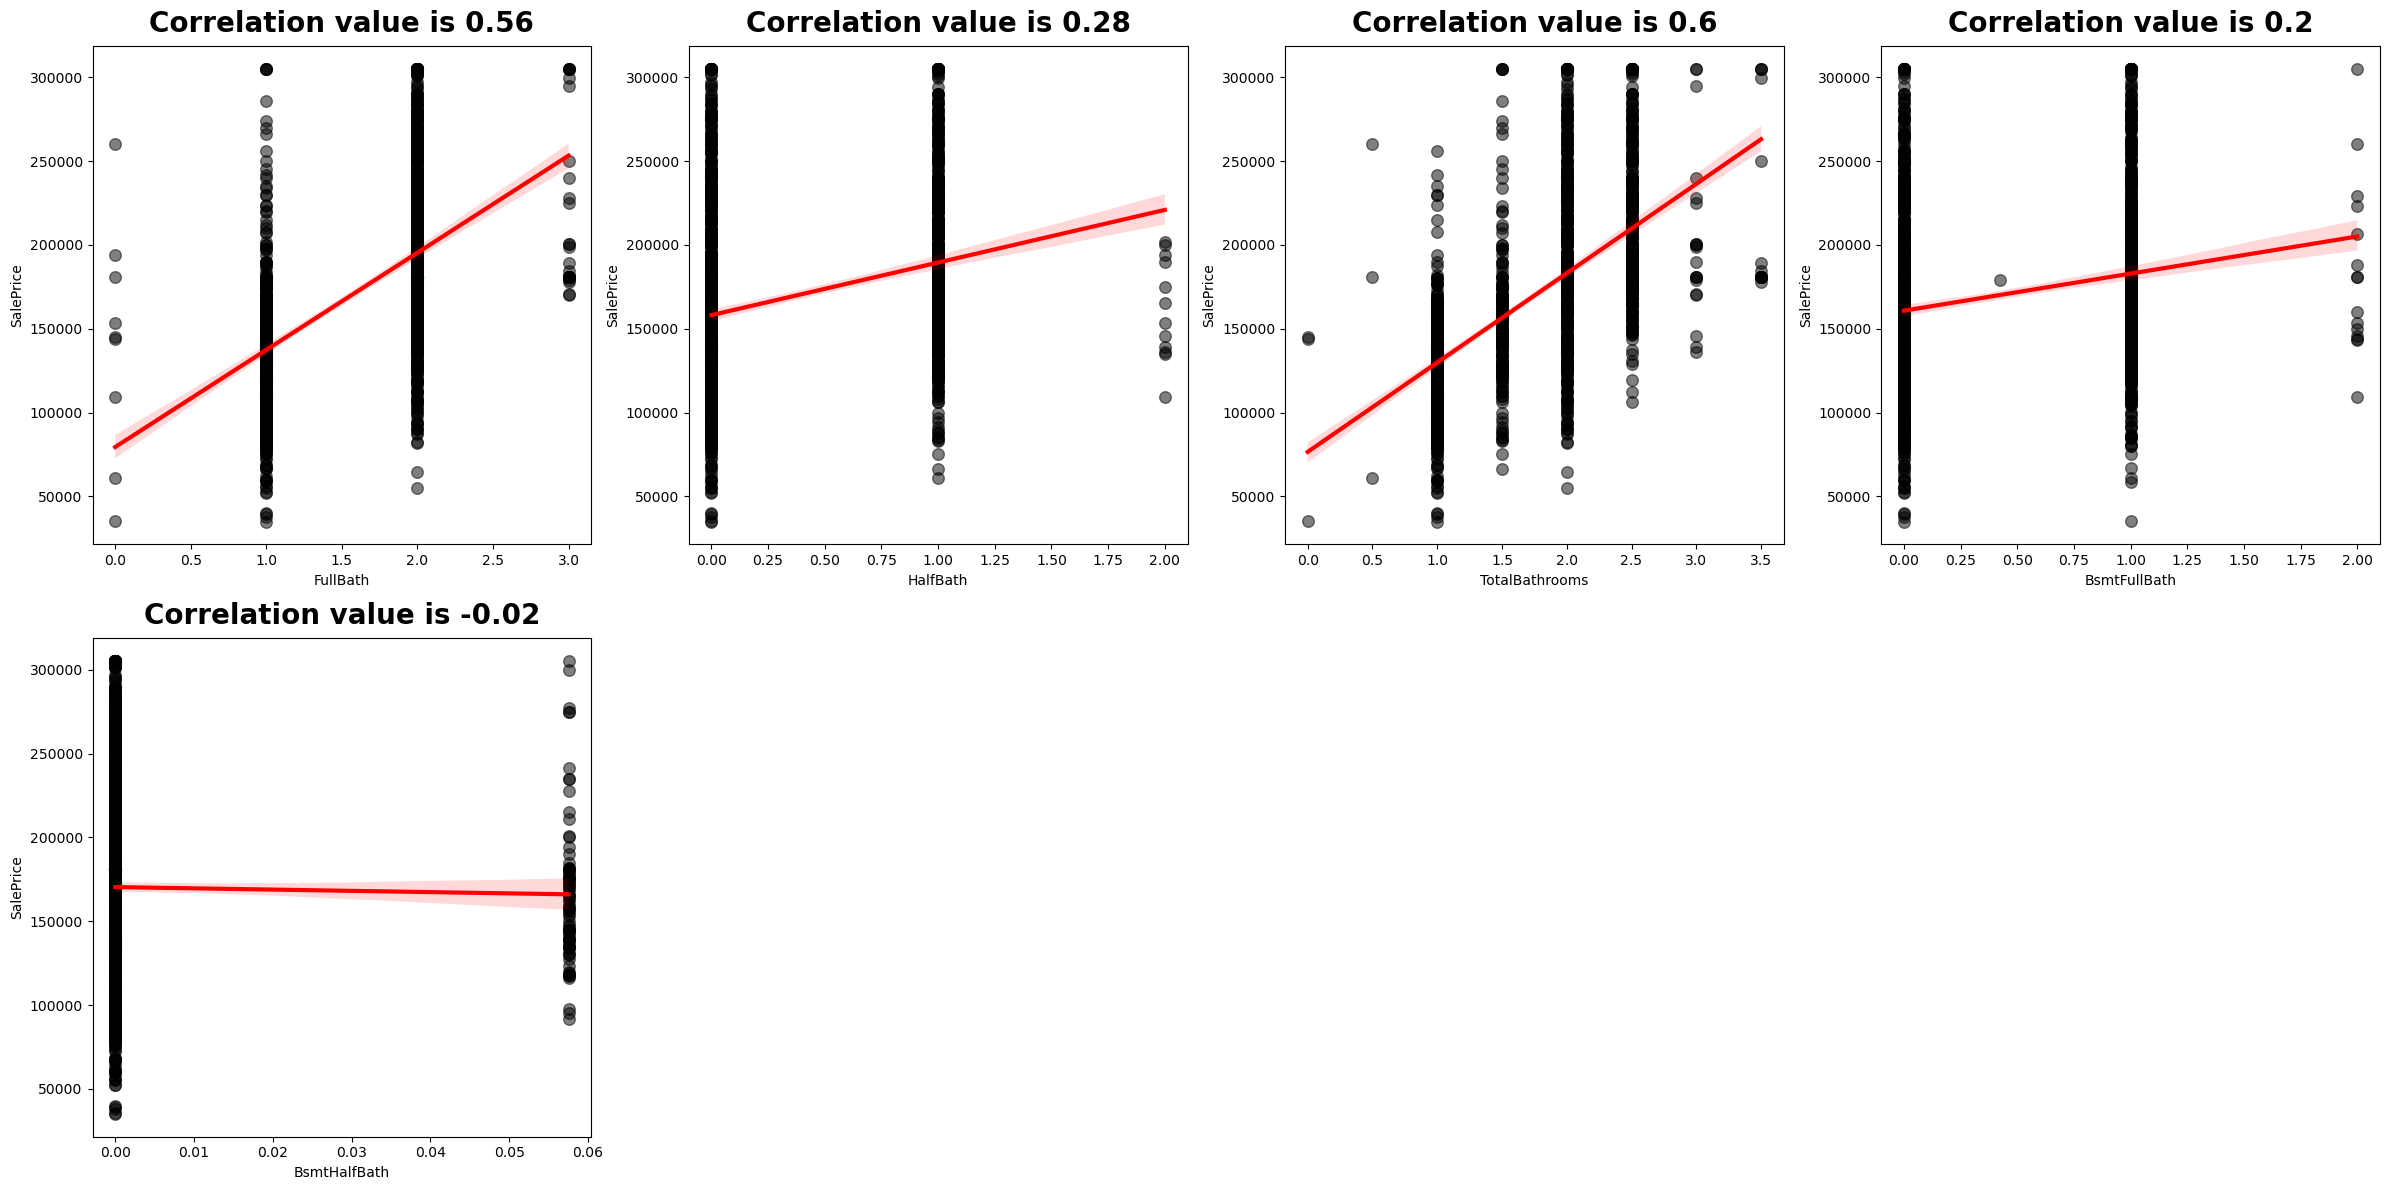

In [1532]:
cols = ['FullBath', 'HalfBath','TotalBathrooms', 'BsmtFullBath', 'BsmtHalfBath']

plt.figure(figsize=(24, 12))
for index, column in enumerate(cols):
    plt.subplot(2, 4, index + 1)
    sns.regplot(x=housing_data[column], y=housing_data["SalePrice"], color="black",
                scatter_kws={'s': 70, 'alpha': 0.5}, line_kws={'color': 'red', 'lw': 3})
    corr = round(housing_data[[column, "SalePrice"]].corr()["SalePrice"][0], 2)
    plt.title(f"Correlation value is {corr}", pad=10, size=20, fontweight="black")
plt.tight_layout()
plt.show()

In [1533]:
housing_data.drop(columns=['FullBath','HalfBath','BsmtFullBath','BsmtHalfBath'],inplace=True)

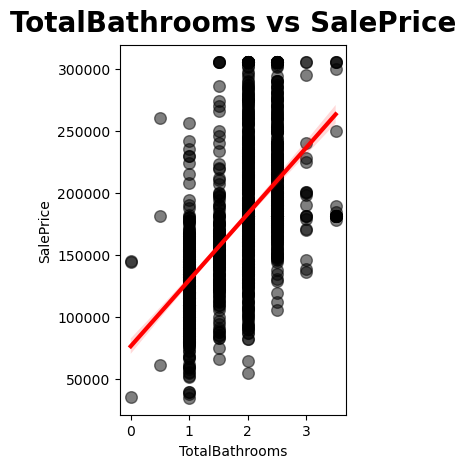

In [1534]:
plt.subplot(1, 2, 2)
sns.regplot(x=housing_data["TotalBathrooms"], y=housing_data["SalePrice"], color="black",
            scatter_kws={'s': 70, 'alpha': 0.5}, line_kws={'color': 'red', 'lw': 3})
plt.title("TotalBathrooms vs SalePrice", pad=10, size=20, fontweight="black")
plt.show()

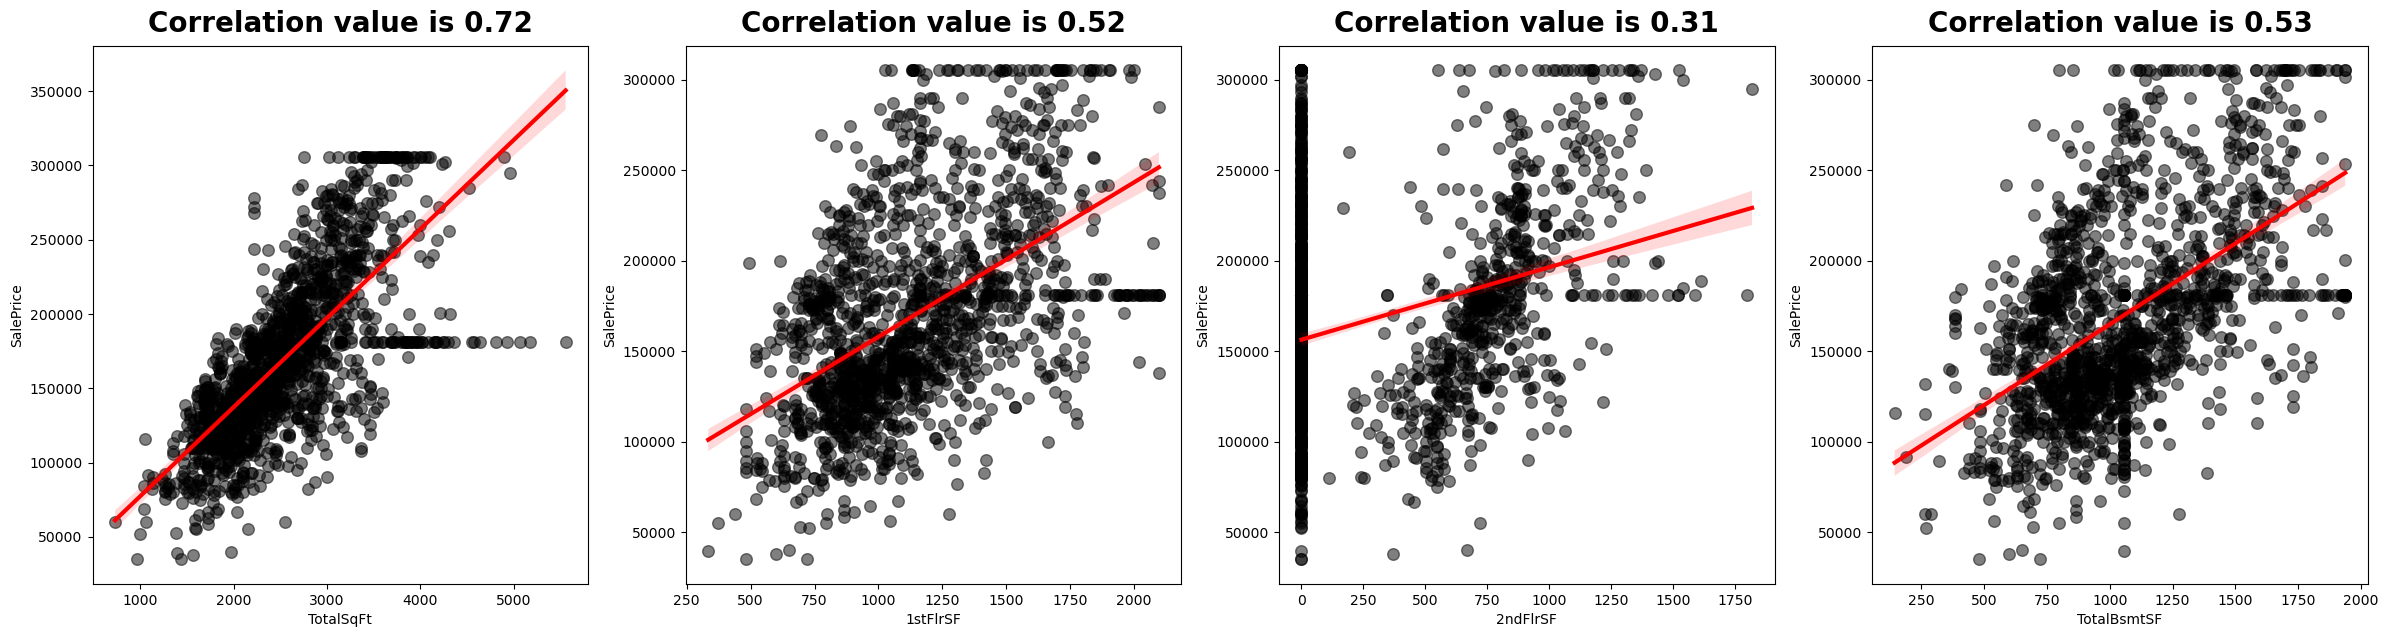

In [1535]:
cols = ['TotalSqFt', '1stFlrSF','2ndFlrSF', 'TotalBsmtSF']

plt.figure(figsize=(24, 12))
for index, column in enumerate(cols):
    plt.subplot(2, 4, index + 1)
    sns.regplot(x=housing_data[column], y=housing_data["SalePrice"], color="black",
                scatter_kws={'s': 70, 'alpha': 0.5}, line_kws={'color': 'red', 'lw': 3})
    corr = round(housing_data[[column, "SalePrice"]].corr()["SalePrice"][0], 2)
    plt.title(f"Correlation value is {corr}", pad=10, size=20, fontweight="black")
plt.tight_layout()
plt.show()

In [1536]:
housing_data.drop(columns=['2ndFlrSF'],inplace=True)

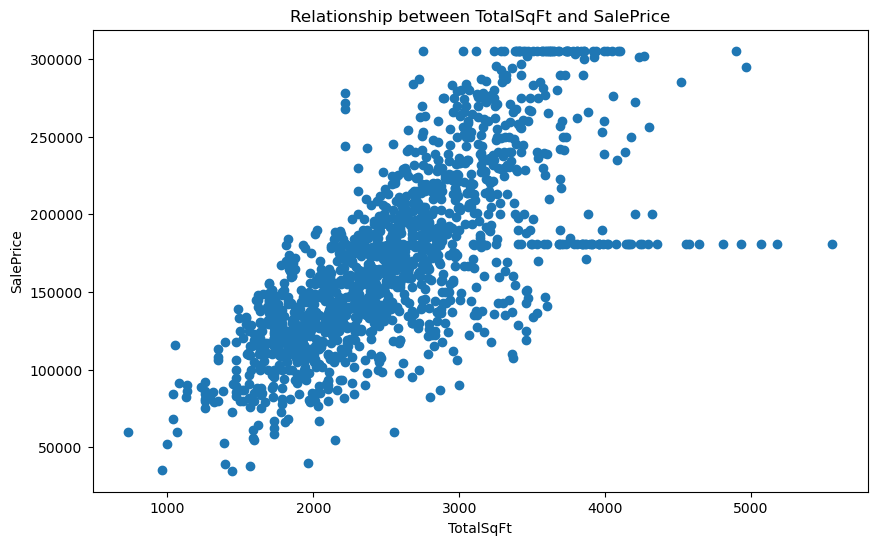

In [1537]:
plt.figure(figsize=(10, 6))
plt.scatter(housing_data['TotalSqFt'],housing_data['SalePrice'])
plt.xlabel('TotalSqFt')
plt.ylabel('SalePrice')
plt.title('Relationship between TotalSqFt and SalePrice')
plt.show()

In [1538]:
housing_data['TotalPorchArea'] = housing_data['OpenPorchSF'] + housing_data['EnclosedPorch'] + housing_data['3SsnPorch'] + housing_data['ScreenPorch']

In [1539]:
housing_data['TotalPorchArea']

0       61.00000
1        0.00000
2       42.00000
3       56.95411
4       84.00000
          ...   
1455    40.00000
1456     0.00000
1457    60.00000
1458    21.95411
1459    68.00000
Name: TotalPorchArea, Length: 1460, dtype: float64

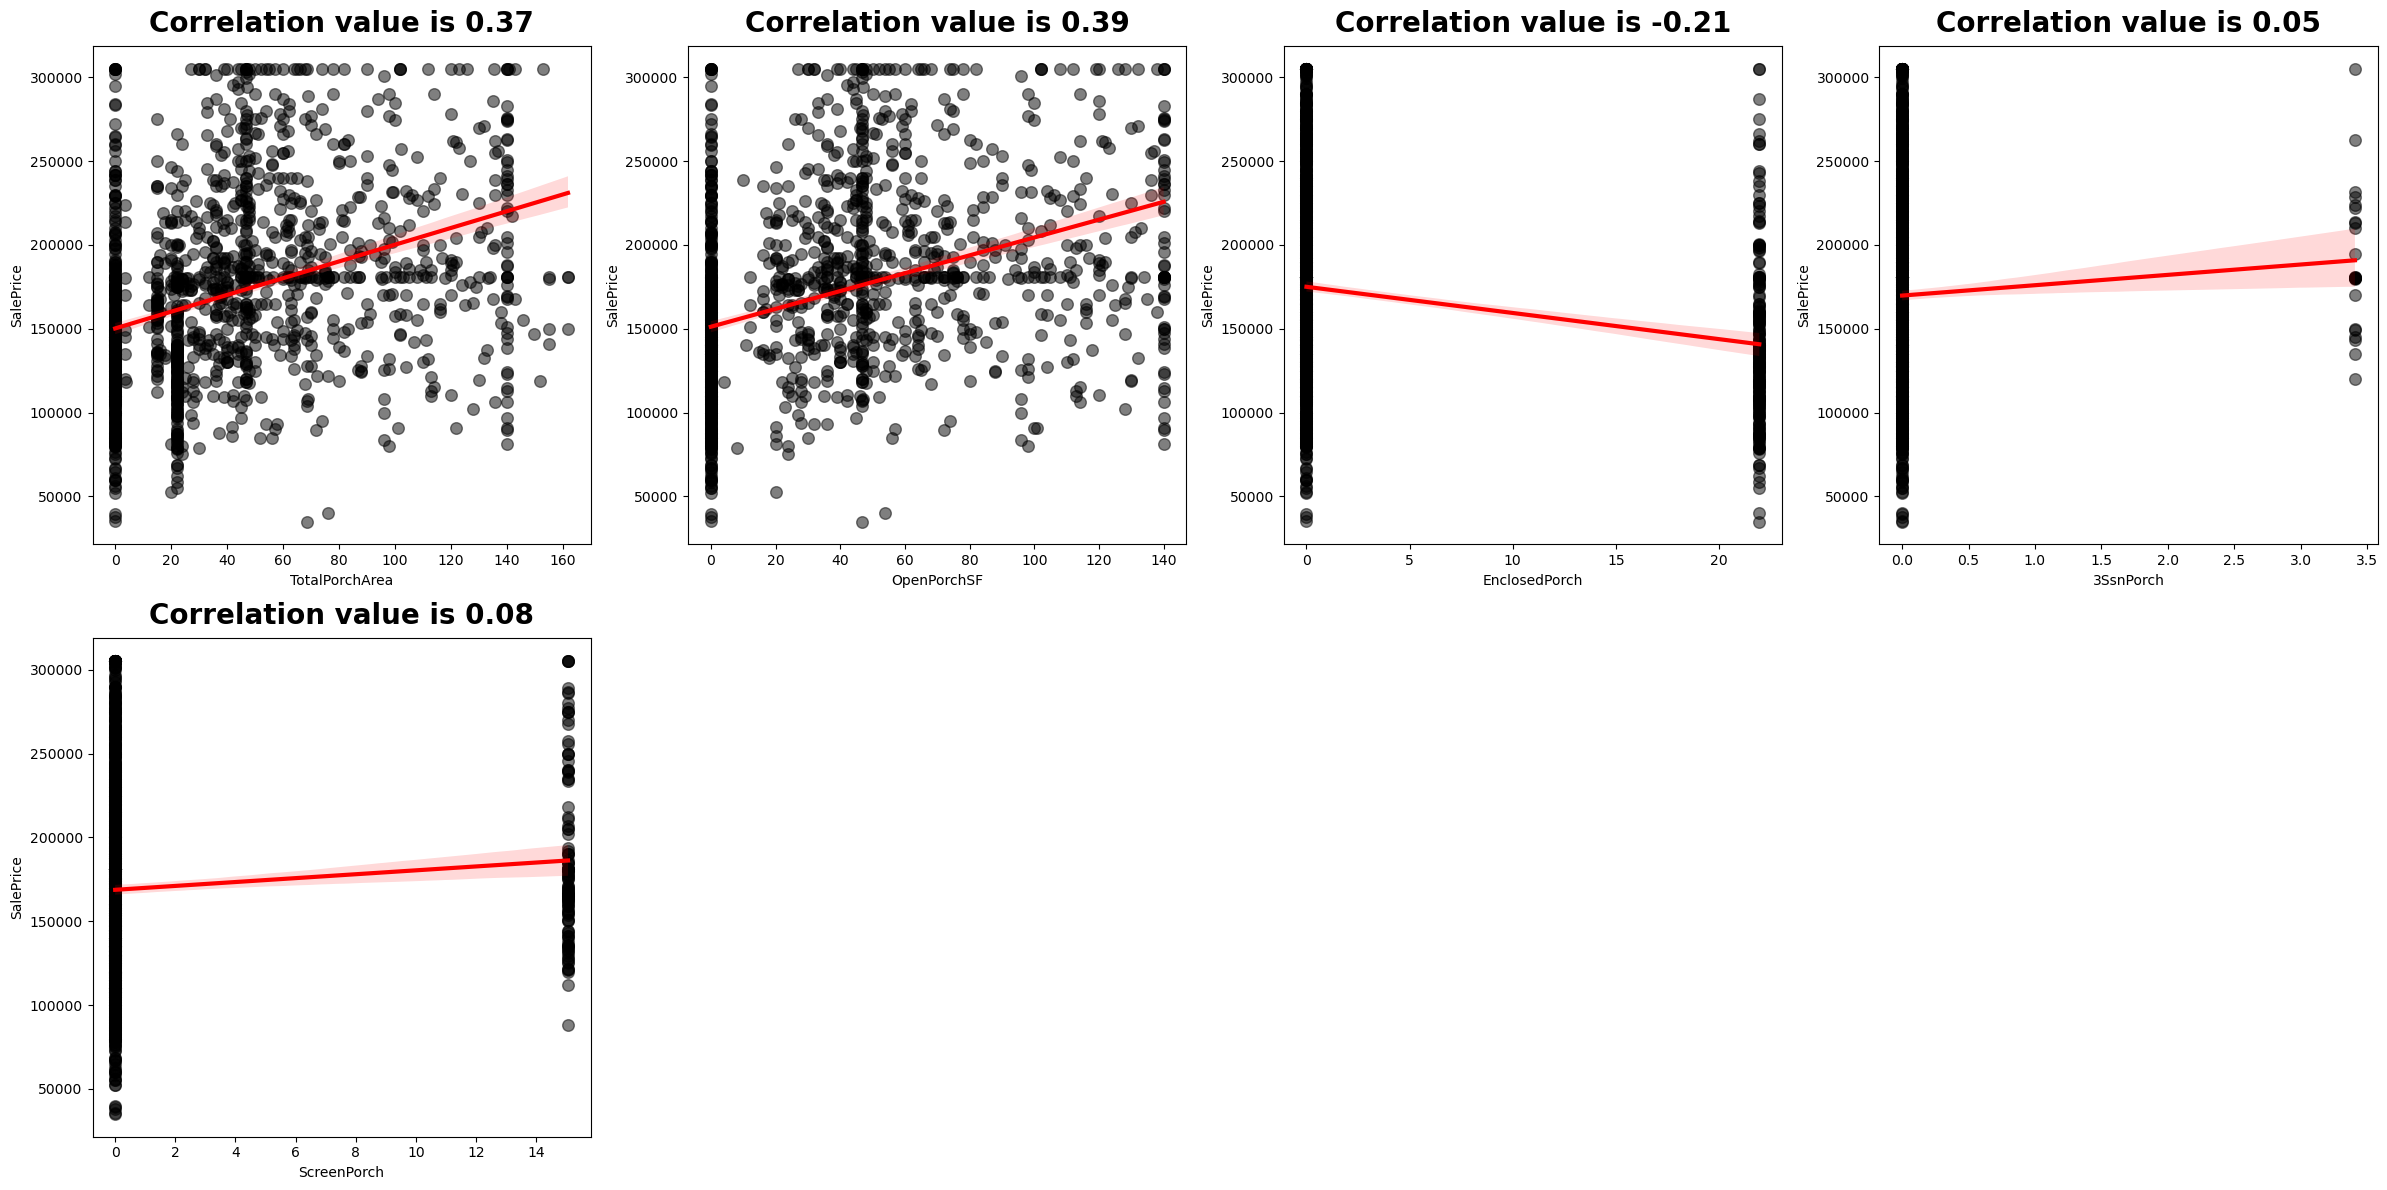

In [1540]:
cols = ['TotalPorchArea', 'OpenPorchSF','EnclosedPorch', '3SsnPorch','ScreenPorch']

plt.figure(figsize=(24, 12))
for index, column in enumerate(cols):
    plt.subplot(2, 4, index + 1)
    sns.regplot(x=housing_data[column], y=housing_data["SalePrice"], color="black",
                scatter_kws={'s': 70, 'alpha': 0.5}, line_kws={'color': 'red', 'lw': 3})
    corr = round(housing_data[[column, "SalePrice"]].corr()["SalePrice"][0], 2)
    plt.title(f"Correlation value is {corr}", pad=10, size=20, fontweight="black")
plt.tight_layout()
plt.show()

In [1541]:
housing_data.drop(columns=['ScreenPorch','3SsnPorch','EnclosedPorch'],inplace=True)

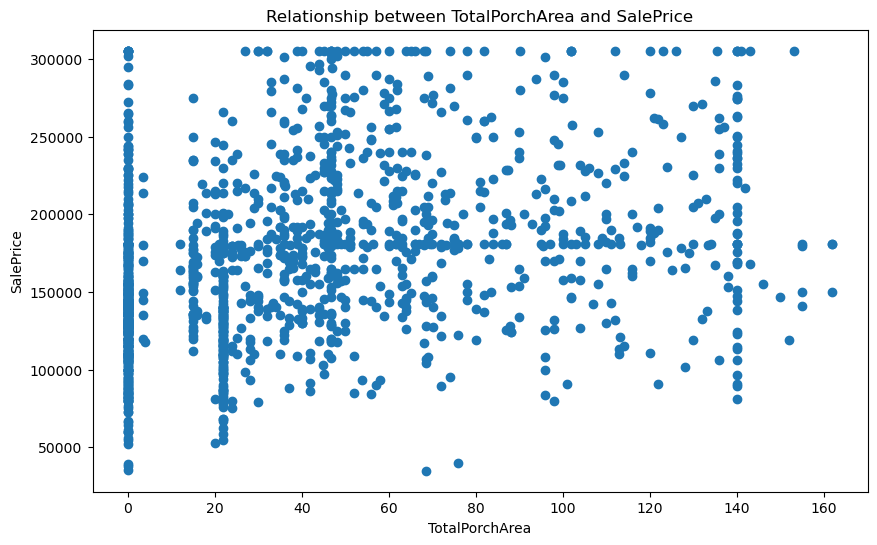

In [1542]:
plt.figure(figsize=(10, 6))
plt.scatter(housing_data['TotalPorchArea'],housing_data['SalePrice'])
plt.xlabel('TotalPorchArea')
plt.ylabel('SalePrice')
plt.title('Relationship between TotalPorchArea and SalePrice')
plt.show()

In [1543]:
housing_data['TotalFinishedSqFt'] = housing_data['BsmtFinSF1'] + housing_data['BsmtFinSF2'] + housing_data['GrLivArea']

In [1544]:
housing_data['TotalFinishedSqFt']

0       2416.000000
1       2240.000000
2       2272.000000
3       1933.000000
4       2853.000000
           ...     
1455    1647.000000
1456    2909.549315
1457    2615.000000
1458    1173.549315
1459    2132.549315
Name: TotalFinishedSqFt, Length: 1460, dtype: float64

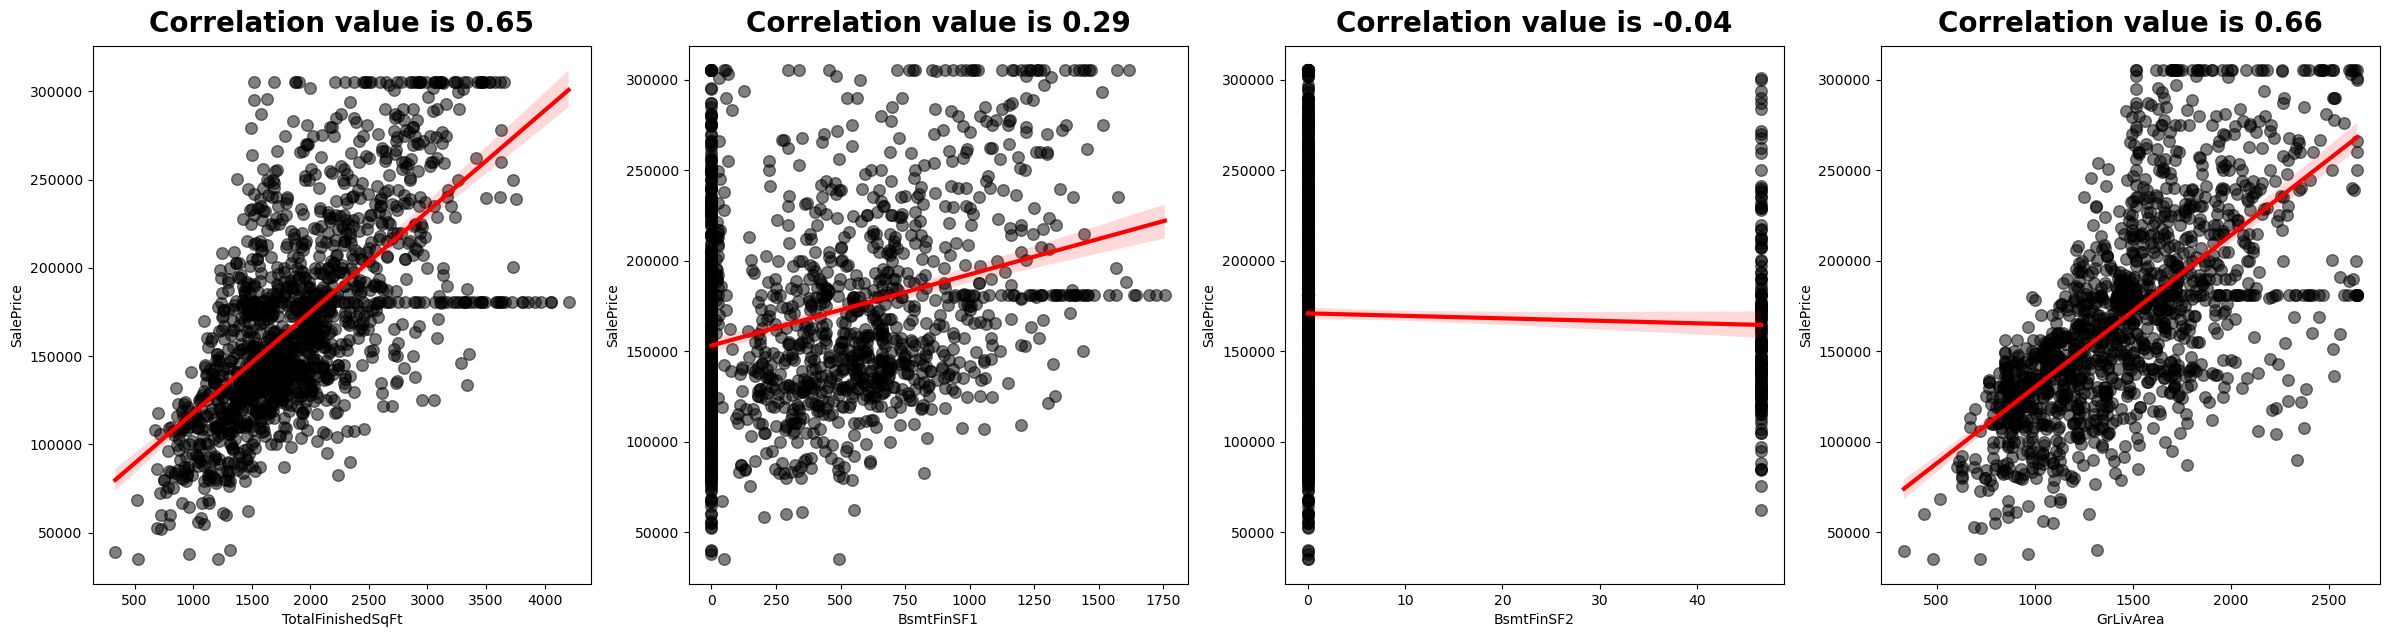

In [1545]:
cols = ['TotalFinishedSqFt', 'BsmtFinSF1','BsmtFinSF2', 'GrLivArea']

plt.figure(figsize=(24, 12))
for index, column in enumerate(cols):
    plt.subplot(2, 4, index + 1)
    sns.regplot(x=housing_data[column], y=housing_data["SalePrice"], color="black",
                scatter_kws={'s': 70, 'alpha': 0.5}, line_kws={'color': 'red', 'lw': 3})
    corr = round(housing_data[[column, "SalePrice"]].corr()["SalePrice"][0], 2)
    plt.title(f"Correlation value is {corr}", pad=10, size=20, fontweight="black")
plt.tight_layout()
plt.show()

In [1546]:
housing_data.drop(columns=['BsmtFinSF2','BsmtFinSF1'],inplace=True)

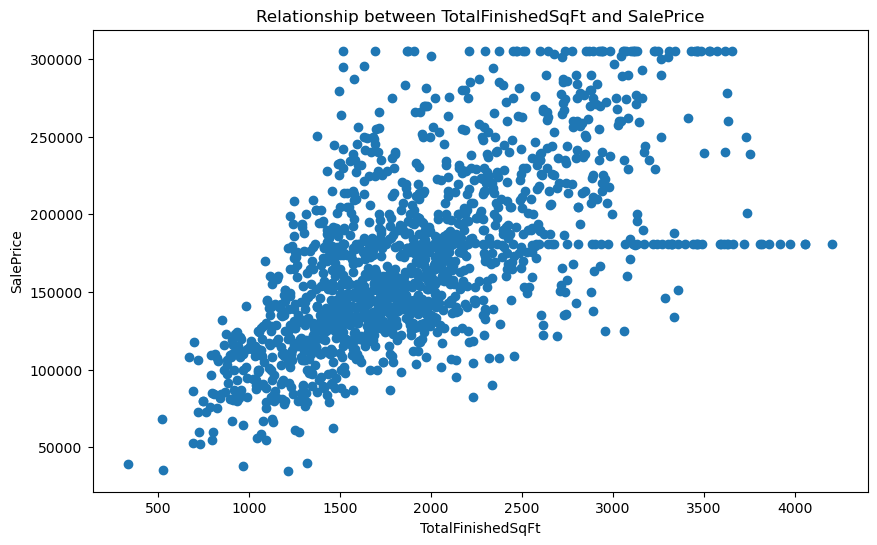

In [1547]:
plt.figure(figsize=(10, 6))
plt.scatter(housing_data['TotalFinishedSqFt'],housing_data['SalePrice'])
plt.xlabel('TotalFinishedSqFt')
plt.ylabel('SalePrice')
plt.title('Relationship between TotalFinishedSqFt and SalePrice')
plt.show()

In [1548]:
housing_data['TotalQualityScore'] = housing_data['OverallQual'] + housing_data['OverallCond']

In [1549]:
housing_data['TotalQualityScore']

0       12.000000
1       11.575342
2       12.000000
3       12.000000
4       13.000000
          ...    
1455    11.000000
1456    12.000000
1457    12.575342
1458    11.000000
1459    11.000000
Name: TotalQualityScore, Length: 1460, dtype: float64

In [1550]:
housing_data['TotalGarageScore'] = housing_data['GarageCars'] * housing_data['GarageArea']

In [1551]:
housing_data['TotalGarageScore']

0       1096.0
1        920.0
2       1216.0
3       1926.0
4       2508.0
         ...  
1455     920.0
1456    1000.0
1457     252.0
1458     240.0
1459     276.0
Name: TotalGarageScore, Length: 1460, dtype: float64

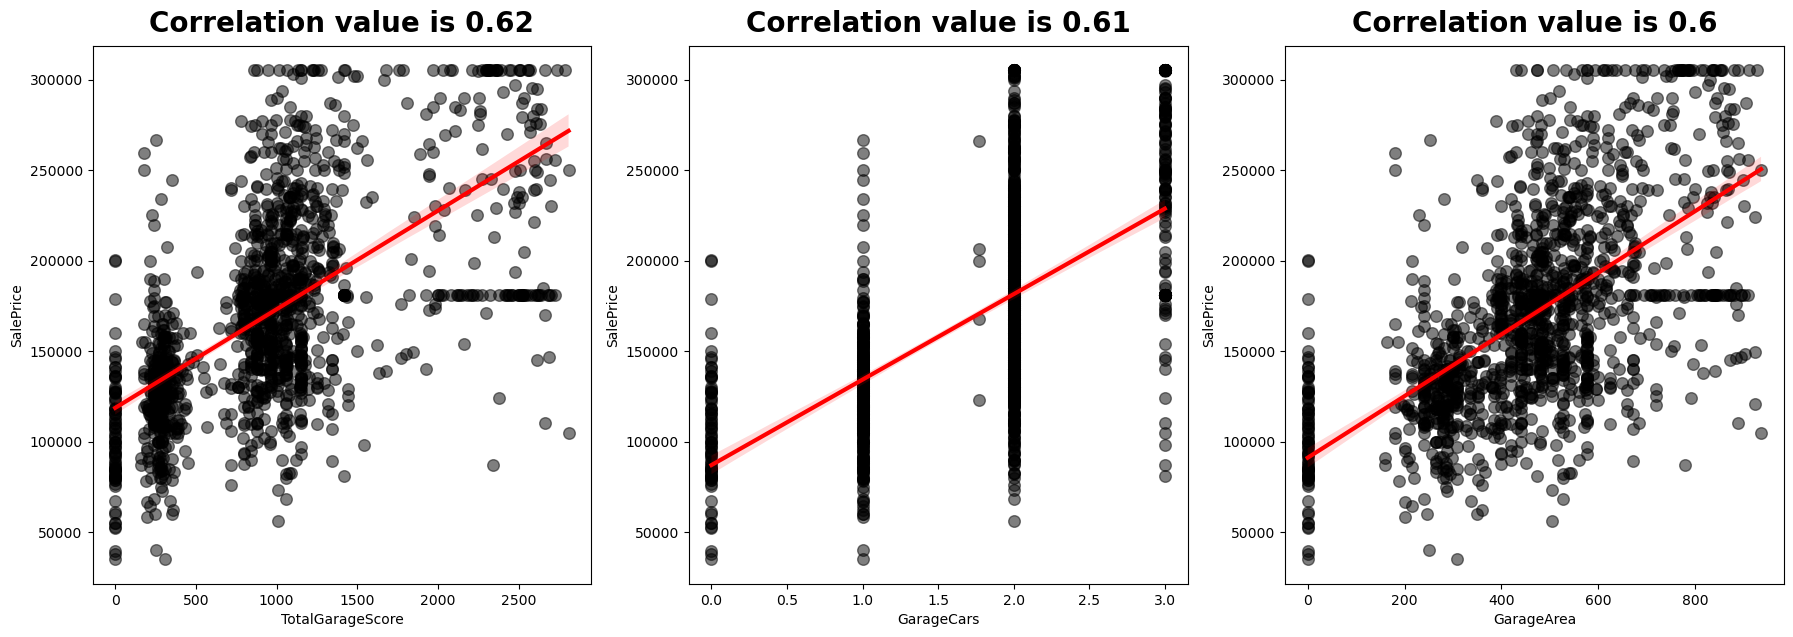

In [1552]:
cols = ['TotalGarageScore', 'GarageCars','GarageArea']
plt.figure(figsize=(24, 12))
for index, column in enumerate(cols):
    plt.subplot(2, 4, index + 1)
    sns.regplot(x=housing_data[column], y=housing_data["SalePrice"], color="black",
                scatter_kws={'s': 70, 'alpha': 0.5}, line_kws={'color': 'red', 'lw': 3})
    corr = round(housing_data[[column, "SalePrice"]].corr()["SalePrice"][0], 2)
    plt.title(f"Correlation value is {corr}", pad=10, size=20, fontweight="black")
plt.tight_layout()
plt.show()

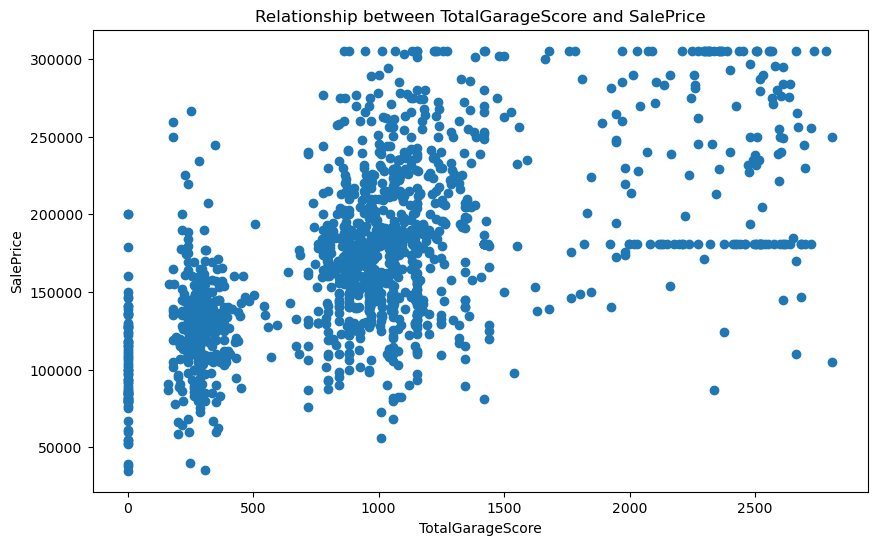

In [1553]:
plt.figure(figsize=(10, 6))
plt.scatter(housing_data['TotalGarageScore'],housing_data['SalePrice'])
plt.xlabel('TotalGarageScore')
plt.ylabel('SalePrice')
plt.title('Relationship between TotalGarageScore and SalePrice')
plt.show()

In [1554]:
housing_data['TotalOutdoorArea'] = housing_data['WoodDeckSF'] + housing_data['OpenPorchSF'] +housing_data['PoolArea']

In [1555]:
housing_data['TotalOutdoorArea']

0        61.000000
1       298.000000
2        42.000000
3        35.000000
4       276.000000
           ...    
1455     40.000000
1456    349.000000
1457     60.000000
1458    366.000000
1459    162.244521
Name: TotalOutdoorArea, Length: 1460, dtype: float64

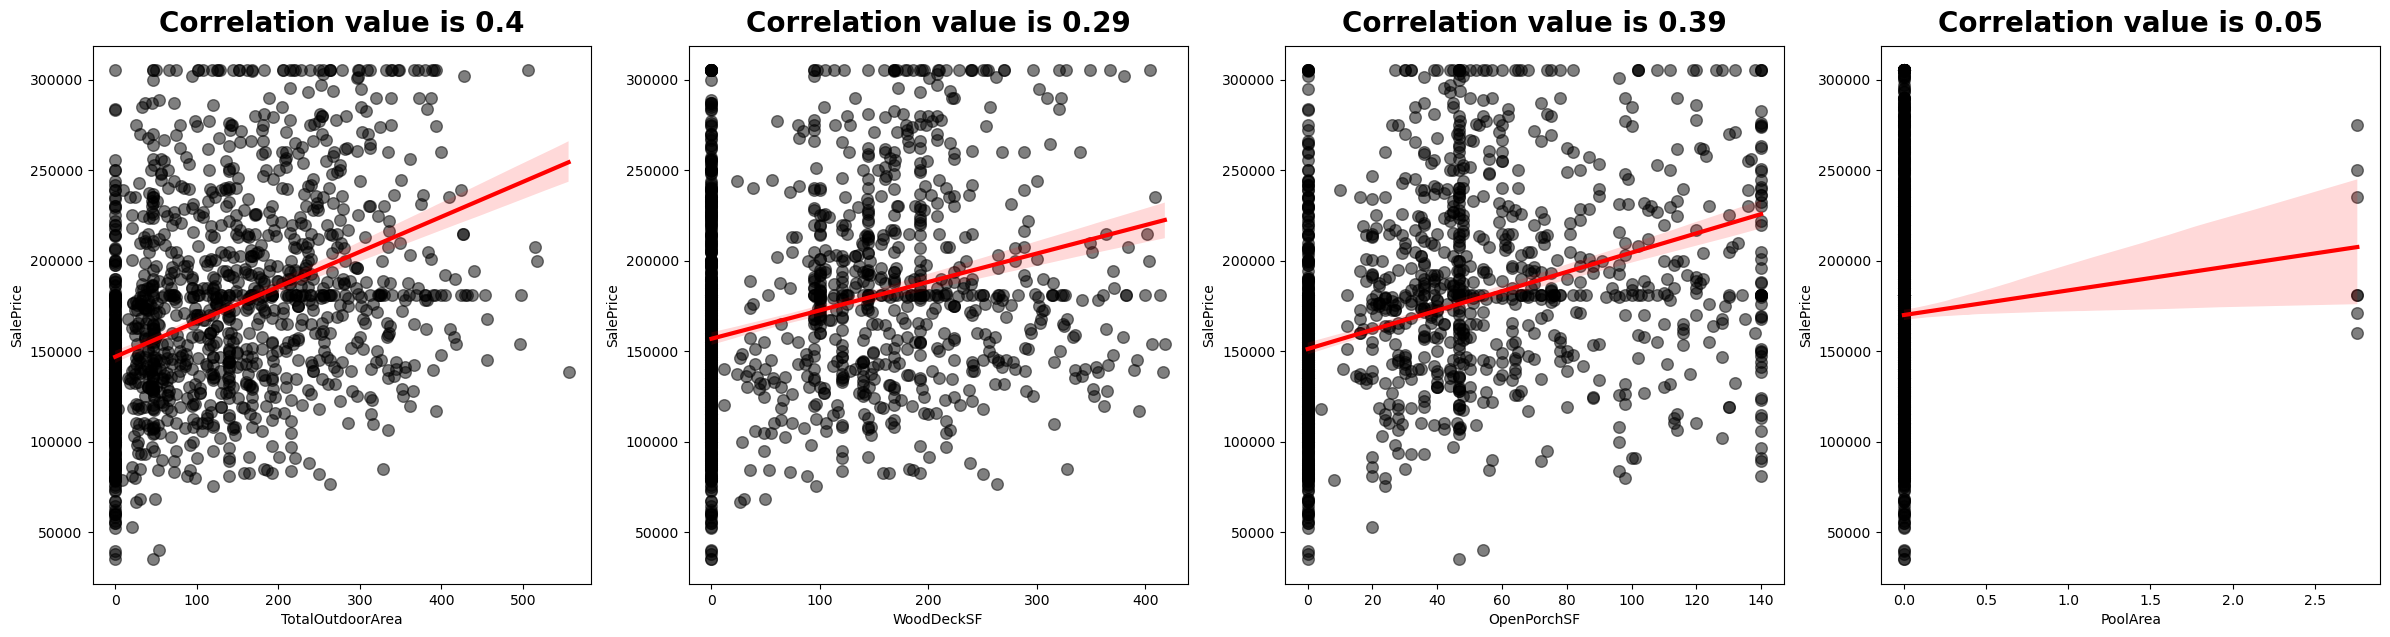

In [1556]:
cols = ['TotalOutdoorArea', 'WoodDeckSF','OpenPorchSF','PoolArea']
plt.figure(figsize=(24, 12))
for index, column in enumerate(cols):
    plt.subplot(2, 4, index + 1)
    sns.regplot(x=housing_data[column], y=housing_data["SalePrice"], color="black",
                scatter_kws={'s': 70, 'alpha': 0.5}, line_kws={'color': 'red', 'lw': 3})
    corr = round(housing_data[[column, "SalePrice"]].corr()["SalePrice"][0], 2)
    plt.title(f"Correlation value is {corr}", pad=10, size=20, fontweight="black")
plt.tight_layout()
plt.show()

In [1557]:
housing_data.drop(columns=['WoodDeckSF','OpenPorchSF','PoolArea'],inplace=True)

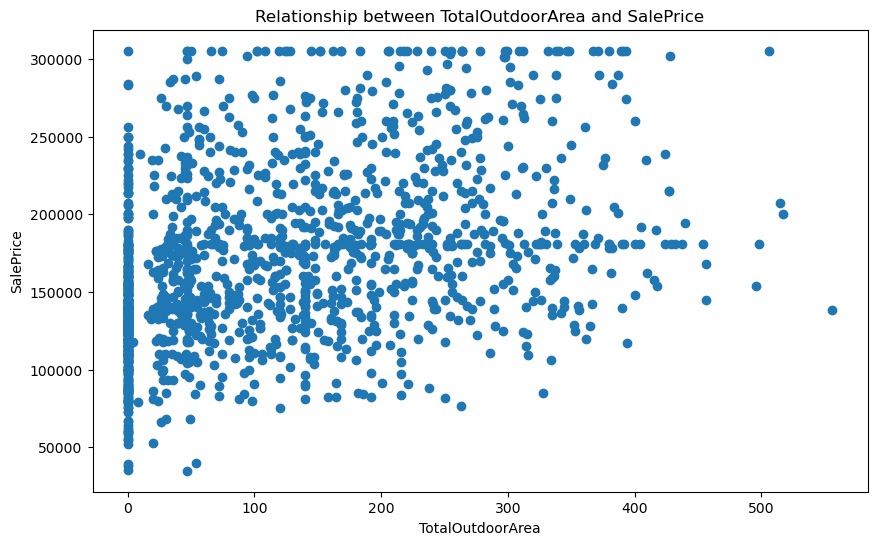

In [1558]:
plt.figure(figsize=(10, 6))
plt.scatter(housing_data['TotalOutdoorArea'],housing_data['SalePrice'])
plt.xlabel('TotalOutdoorArea')
plt.ylabel('SalePrice')
plt.title('Relationship between TotalOutdoorArea and SalePrice')
plt.show()

In [1559]:
housing_data.shape

(1460, 30)

In [1560]:
housing_data.head()

,LotFrontage,LotArea,OverallQual,OverallCond,YearRemodAdd,MasVnrArea,BsmtUnfSF,TotalBsmtSF,1stFlrSF,Low_quality_finished_square_feet,...,SalePrice,PricePerSqFt,AgeAtSale,TotalSqFt,TotalBathrooms,TotalPorchArea,TotalFinishedSqFt,TotalQualityScore,TotalGarageScore,TotalOutdoorArea
0,65.0,8450.0,7.0,5.000000,2003.0,196.0,150.0,856.0,856.0,0.0,...,208500.0,81.254871,5.0,2566.0,2.5,61.00000,2416.0,12.000000,1096.0,61.0
1,80.0,9600.0,6.0,5.575342,1976.0,0.0,284.0,1262.0,1262.0,0.0,...,181500.0,71.909667,31.0,2524.0,2.0,0.00000,2240.0,11.575342,920.0,298.0
2,68.0,11250.0,7.0,5.000000,2002.0,162.0,434.0,920.0,920.0,0.0,...,223500.0,82.594235,7.0,2706.0,2.5,42.00000,2272.0,12.000000,1216.0,42.0
3,60.0,9550.0,7.0,5.000000,1970.0,0.0,540.0,756.0,961.0,0.0,...,140000.0,56.611403,91.0,2473.0,1.0,56.95411,1933.0,12.000000,1926.0,35.0
4,84.0,14260.0,8.0,5.000000,2000.0,265.0,490.0,1145.0,1145.0,0.0,...,250000.0,74.783129,8.0,3343.0,2.5,84.00000,2853.0,13.000000,2508.0,276.0


In [1561]:
housing_data.shape

(1460, 30)

In [1562]:
housing_data.head()

,LotFrontage,LotArea,OverallQual,OverallCond,YearRemodAdd,MasVnrArea,BsmtUnfSF,TotalBsmtSF,1stFlrSF,Low_quality_finished_square_feet,...,SalePrice,PricePerSqFt,AgeAtSale,TotalSqFt,TotalBathrooms,TotalPorchArea,TotalFinishedSqFt,TotalQualityScore,TotalGarageScore,TotalOutdoorArea
0,65.0,8450.0,7.0,5.000000,2003.0,196.0,150.0,856.0,856.0,0.0,...,208500.0,81.254871,5.0,2566.0,2.5,61.00000,2416.0,12.000000,1096.0,61.0
1,80.0,9600.0,6.0,5.575342,1976.0,0.0,284.0,1262.0,1262.0,0.0,...,181500.0,71.909667,31.0,2524.0,2.0,0.00000,2240.0,11.575342,920.0,298.0
2,68.0,11250.0,7.0,5.000000,2002.0,162.0,434.0,920.0,920.0,0.0,...,223500.0,82.594235,7.0,2706.0,2.5,42.00000,2272.0,12.000000,1216.0,42.0
3,60.0,9550.0,7.0,5.000000,1970.0,0.0,540.0,756.0,961.0,0.0,...,140000.0,56.611403,91.0,2473.0,1.0,56.95411,1933.0,12.000000,1926.0,35.0
4,84.0,14260.0,8.0,5.000000,2000.0,265.0,490.0,1145.0,1145.0,0.0,...,250000.0,74.783129,8.0,3343.0,2.5,84.00000,2853.0,13.000000,2508.0,276.0


In [1563]:
housing_data.shape

(1460, 30)

In [1564]:
housing_data.tail()

,LotFrontage,LotArea,OverallQual,OverallCond,YearRemodAdd,MasVnrArea,BsmtUnfSF,TotalBsmtSF,1stFlrSF,Low_quality_finished_square_feet,...,SalePrice,PricePerSqFt,AgeAtSale,TotalSqFt,TotalBathrooms,TotalPorchArea,TotalFinishedSqFt,TotalQualityScore,TotalGarageScore,TotalOutdoorArea
1455,62.0,7917.0,6.0,5.000000,2000.0,0.0,953.0,953.0,953.0,0.0,...,175000.0,67.307692,8.0,2600.0,2.5,40.00000,1647.000000,11.000000,920.0,40.000000
1456,85.0,13175.0,6.0,6.000000,1988.0,119.0,589.0,1542.0,2073.0,0.0,...,210000.0,58.091286,32.0,3615.0,2.0,0.00000,2909.549315,12.000000,1000.0,349.000000
1457,66.0,9042.0,7.0,5.575342,2006.0,0.0,877.0,1152.0,1188.0,0.0,...,266500.0,76.317297,69.0,3492.0,2.0,60.00000,2615.000000,12.575342,252.0,60.000000
1458,68.0,9717.0,5.0,6.000000,1996.0,0.0,0.0,1078.0,1078.0,0.0,...,142125.0,65.920686,60.0,2156.0,1.0,21.95411,1173.549315,11.000000,240.0,366.000000
1459,75.0,9937.0,5.0,6.000000,1965.0,0.0,136.0,1256.0,1256.0,0.0,...,147500.0,58.718153,43.0,2512.0,1.5,68.00000,2132.549315,11.000000,276.0,162.244521


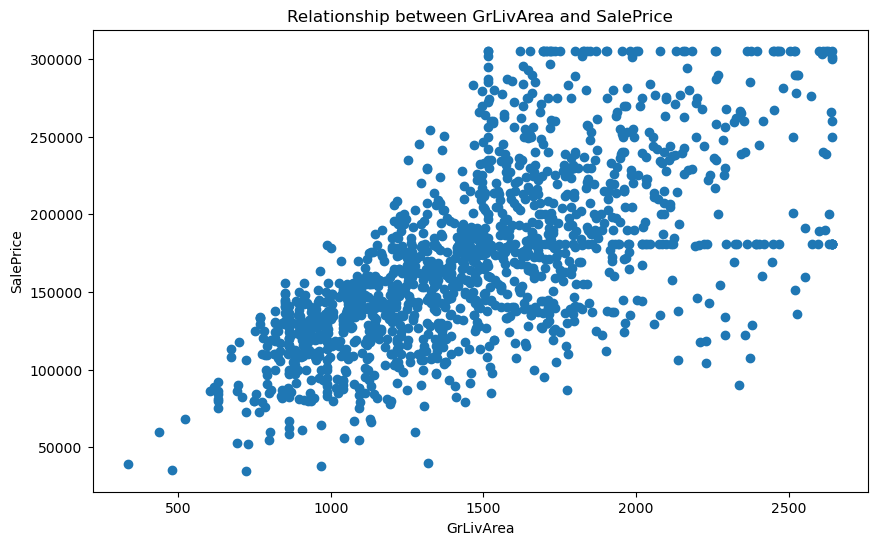

In [1565]:
plt.figure(figsize=(10, 6))
plt.scatter(housing_data['GrLivArea'],housing_data['SalePrice'])
plt.xlabel('GrLivArea')
plt.ylabel('SalePrice')
plt.title('Relationship between GrLivArea and SalePrice')
plt.show()

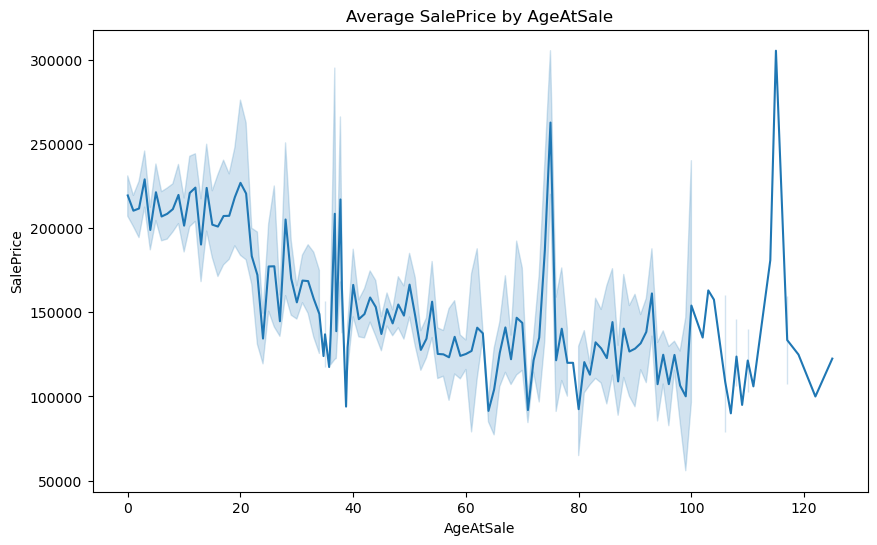

In [1566]:
plt.figure(figsize=(10, 6))
sns.lineplot(x='AgeAtSale', y='SalePrice', data=housing_data)
plt.xlabel('AgeAtSale')
plt.ylabel('SalePrice')
plt.title('Average SalePrice by AgeAtSale')
plt.show()


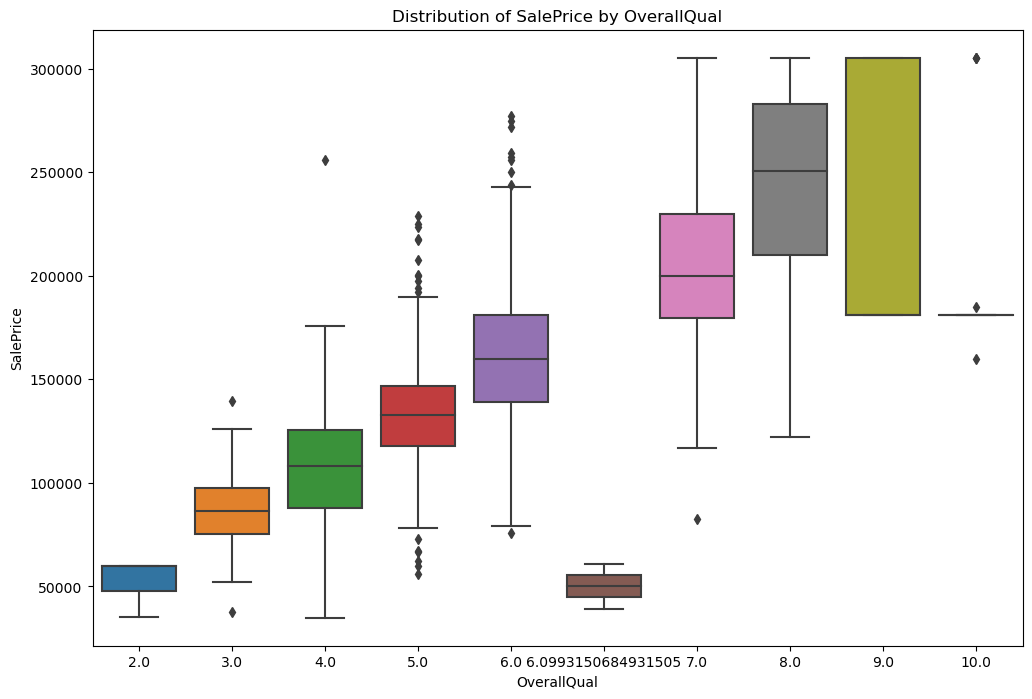

In [1567]:
plt.figure(figsize=(12, 8))
sns.boxplot(x='OverallQual', y='SalePrice', data=housing_data)
plt.xlabel('OverallQual')
plt.ylabel('SalePrice')
plt.title('Distribution of SalePrice by OverallQual')
plt.show()

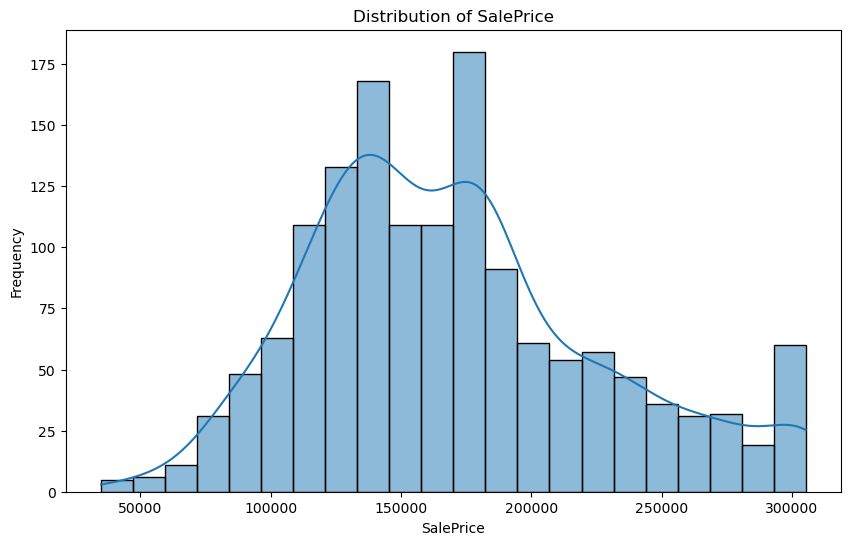

In [1568]:
plt.figure(figsize=(10, 6))
sns.histplot(housing_data['SalePrice'], kde=True)
plt.xlabel('SalePrice')
plt.ylabel('Frequency')
plt.title('Distribution of SalePrice')
plt.show()

In [1569]:
from sklearn.preprocessing import MinMaxScaler

In [1570]:
scaler = MinMaxScaler()
encoding_housing_data[['TotalSqFt', 'TotalBathrooms']] = scaler.fit_transform(encoding_housing_data[['TotalSqFt', 'TotalBathrooms']])

In [1571]:
scaler = MinMaxScaler()
encoding_housing_data[['TotalSqFt', 'TotalBathrooms']] = scaler.fit_transform(encoding_housing_data[['TotalSqFt', 'TotalBathrooms']])

In [1572]:
housing_data[['TotalSqFt', 'TotalBathrooms']]

,TotalSqFt,TotalBathrooms
0,2566.0,2.5
1,2524.0,2.0
2,2706.0,2.5
3,2473.0,1.0
4,3343.0,2.5
...,...,...
1455,2600.0,2.5
1456,3615.0,2.0
1457,3492.0,2.0
1458,2156.0,1.0


In [1573]:
selected_features = ['TotalSqFt', 'TotalBathrooms', 'Neighborhood_NAmes', 'HouseStyle_2Story']
x = encoding_housing_data[selected_features]
y = encoding_housing_data['SalePrice']

In [1574]:
x

,TotalSqFt,TotalBathrooms,Neighborhood_NAmes,HouseStyle_2Story
0,0.195481,0.714286,0,1
1,0.191802,0.571429,0,0
2,0.207742,0.714286,0,1
3,0.187336,0.285714,0,1
4,0.263531,0.714286,0,1
...,...,...,...,...
1455,0.198459,0.714286,0,1
1456,0.287353,0.571429,0,0
1457,0.276581,0.571429,0,1
1458,0.159573,0.285714,1,0


In [1575]:
y

0       208500
1       181500
2       223500
3       140000
4       250000
         ...  
1455    175000
1456    210000
1457    266500
1458    142125
1459    147500
Name: SalePrice, Length: 1460, dtype: int64

In [1576]:
correlation_matrix = encoding_housing_data.corr()

In [1577]:
correlation_with_saleprice = correlation_matrix['SalePrice'].sort_values(ascending=False)

In [1578]:
print(correlation_with_saleprice.head(10))

SalePrice            1.000000
OverallQual          0.790982
TotalSqFt            0.782260
GrLivArea            0.708624
TotalFinishedSqFt    0.705327
TotalGarageScore     0.680058
PricePerSqFt         0.640819
GarageCars           0.640409
GarageArea           0.623431
TotalBsmtSF          0.613581
Name: SalePrice, dtype: float64


In [1579]:
print(correlation_with_saleprice.tail(10))

HeatingQC_TA             -0.312677
BsmtExposure_No          -0.319990
Foundation_CBlock        -0.343263
Garage_location_Detchd   -0.354141
GarageFinish_Unf         -0.410608
BsmtQual_TA              -0.452394
FireplaceQu_No           -0.471908
Kitchen_Quality_TA       -0.519298
AgeAtSale                -0.523350
ExterQual_TA             -0.589044
Name: SalePrice, dtype: float64


In [1580]:
from sklearn.model_selection import train_test_split

In [1581]:
X=encoding_housing_data.drop('SalePrice',axis=1)
Y=encoding_housing_data.SalePrice

In [1582]:
X

,LotFrontage,LotArea,OverallQual,OverallCond,YearRemodAdd,MasVnrArea,BsmtUnfSF,TotalBsmtSF,1stFlrSF,Low_quality_finished_square_feet,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,65,8450,7,5,2003,196,150,856,856,0,...,0,0,0,0,1,0,0,0,1,0
1,80,9600,6,8,1976,0,284,1262,1262,0,...,0,0,0,0,1,0,0,0,1,0
2,68,11250,7,5,2002,162,434,920,920,0,...,0,0,0,0,1,0,0,0,1,0
3,60,9550,7,5,1970,0,540,756,961,0,...,0,0,0,0,1,0,0,0,0,0
4,84,14260,8,5,2000,350,490,1145,1145,0,...,0,0,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,62,7917,6,5,2000,0,953,953,953,0,...,0,0,0,0,1,0,0,0,1,0
1456,85,13175,6,6,1988,119,589,1542,2073,0,...,0,0,0,0,1,0,0,0,1,0
1457,66,9042,7,9,2006,0,877,1152,1188,0,...,0,0,0,0,1,0,0,0,1,0
1458,68,9717,5,6,1996,0,0,1078,1078,0,...,0,0,0,0,1,0,0,0,1,0


In [1583]:
Y

0       208500
1       181500
2       223500
3       140000
4       250000
         ...  
1455    175000
1456    210000
1457    266500
1458    142125
1459    147500
Name: SalePrice, Length: 1460, dtype: int64

In [1584]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [1585]:
X_train

,LotFrontage,LotArea,OverallQual,OverallCond,YearRemodAdd,MasVnrArea,BsmtUnfSF,TotalBsmtSF,1stFlrSF,Low_quality_finished_square_feet,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
254,70,8400,5,6,1957,0,392,1314,1314,0,...,0,0,0,0,1,0,0,0,1,0
1066,59,7837,6,7,1994,0,799,799,799,0,...,0,0,0,0,1,0,0,0,1,0
638,67,8777,5,7,1950,0,796,796,796,0,...,0,0,0,0,1,0,0,0,1,0
799,60,7200,5,7,1950,252,162,731,981,0,...,0,0,0,0,1,0,0,0,1,0
380,50,5000,5,6,1950,0,808,1026,1026,0,...,0,0,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1095,78,9317,6,5,2006,0,1290,1314,1314,0,...,0,0,0,0,1,0,0,0,1,0
1130,65,7804,4,3,1950,0,500,1122,1328,0,...,0,0,0,0,1,0,0,0,1,0
1294,60,8172,5,7,1990,0,697,864,864,0,...,0,0,0,0,1,0,0,0,1,0
860,55,7642,7,8,1998,0,912,912,912,0,...,0,0,0,0,1,0,0,0,1,0


In [1586]:
X_test

,LotFrontage,LotArea,OverallQual,OverallCond,YearRemodAdd,MasVnrArea,BsmtUnfSF,TotalBsmtSF,1stFlrSF,Low_quality_finished_square_feet,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
892,70,8414,6,8,2003,0,396,1059,1068,0,...,0,0,0,0,1,0,0,0,1,0
1105,98,12256,8,5,1995,362,431,1463,1500,0,...,0,0,0,0,1,0,0,0,1,0
413,56,8960,5,6,1950,0,1008,1008,1028,0,...,0,0,0,0,1,0,0,0,1,0
522,50,5000,6,7,1950,0,605,1004,1004,0,...,0,0,0,0,1,0,0,0,1,0
1036,89,12898,9,5,2008,70,598,1620,1620,0,...,0,0,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
479,50,5925,4,7,2000,435,739,907,1131,0,...,0,0,0,0,1,0,1,0,0,0
1361,124,16158,7,5,2005,16,256,1530,1530,0,...,0,0,0,0,1,0,0,0,1,0
802,63,8199,7,5,2005,0,80,728,728,0,...,0,0,0,0,1,0,0,0,1,0
651,60,9084,4,5,1950,0,755,755,755,0,...,0,0,0,0,1,0,0,0,1,0


In [1587]:
Y_test

892     154500
1105    325000
413     115000
522     159000
1036    315500
         ...  
479      89471
1361    260000
802     189000
651     108000
722     124500
Name: SalePrice, Length: 292, dtype: int64

In [1588]:
Y_train

254     145000
1066    178000
638      85000
799     175000
380     127000
         ...  
1095    176432
1130    135000
1294    115000
860     189950
1126    174000
Name: SalePrice, Length: 1168, dtype: int64

In [1589]:
from sklearn.ensemble import RandomForestRegressor

In [1590]:
model = RandomForestRegressor()

In [1591]:
model.fit(X_train,Y_train)

RandomForestRegressor()

In [1592]:
y_pred = model.predict(X_test)

In [1593]:
y_pred

array([153099.8 , 346489.87, 113073.32, 162589.9 , 318019.74,  82633.5 ,
       253272.75, 147238.87,  85892.  , 134795.5 , 146320.5 , 129886.  ,
        86952.16, 216660.28, 177606.19, 134837.  , 183646.56, 134924.  ,
       117296.62, 225504.1 , 153745.5 , 217762.86, 173955.92, 127569.7 ,
       190608.5 , 156390.14, 181228.16, 132994.5 , 180106.14, 209355.09,
       131023.1 , 273514.24, 182441.  , 134043.4 , 256501.38, 141982.5 ,
       139667.5 , 215331.8 , 310890.41, 102734.5 ,  99011.  , 208178.5 ,
       119850.  , 257728.25, 129863.  , 119614.83, 117986.  , 125939.  ,
       441419.25, 144843.37, 121644.5 , 195549.  , 117391.7 , 315050.  ,
       141856.  , 256349.14, 215228.5 , 173859.  , 109469.33, 105002.5 ,
        79404.  , 157132.15, 321642.18, 274161.48, 290382.58, 242426.52,
       109416.5 , 308599.7 ,  97360.5 , 175957.6 , 122141.78, 134901.5 ,
       110101.5 ,  89447.  , 520778.91, 172676.95, 336324.89, 331103.57,
       142197.  , 126799.08, 110627.56,  79439.66, 

In [1594]:
score = model.score(X_test, Y_test)
print(f'Model Score: {score}')

Model Score: 0.9749217268044588


In [1595]:
from sklearn.metrics import mean_squared_error, r2_score

In [1596]:
mse = mean_squared_error(Y_test, y_pred)
r2 = r2_score(Y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')

Mean Squared Error: 192358536.1227586
R-squared: 0.9749217268044588


In [1597]:
from sklearn.linear_model import LinearRegression

In [1598]:
model = LinearRegression()

In [1599]:
model.fit(X_train,Y_train)

LinearRegression()

In [1600]:
Y_pred = model.predict(X_test)

In [1601]:
Y_pred

array([ 155834.53736845,  338060.18951049,   99866.86992923,
        159021.50507417,  315216.58709572,   64381.07876678,
        310090.51722851,  142032.70521605,   83936.75210109,
        144167.41548721,  141593.31838553,  140746.6081654 ,
         51478.39277278,  218105.49673923,  176738.9916562 ,
        132612.247506  ,  177964.38343142,  128659.48464585,
        124319.63447357,  223790.71209828,  162610.03057535,
        215691.17215502,  174217.51110072,  124126.30832556,
        187806.48576313,  140352.38056425,  173610.28378741,
        150575.26044831,  178285.6141857 ,  200167.0345512 ,
        148022.17031487,  290550.99044195,  259485.85651562,
        129928.04999672,  251318.14072765,  136801.25795037,
        150015.57401676,  214380.05694295,  307630.26357875,
        140432.25444592,   92501.81196964,  208752.85069685,
        113726.05884707,  312171.2256511 ,  123823.12052506,
        141188.92430253,  112515.91253711,  126938.22967748,
        439869.62203369,

In [1602]:
score = model.score(X_test, Y_test)
print(f'Model Score: {score}')

Model Score: 0.8179650559777571


In [1603]:
mse = mean_squared_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)

print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')

Mean Squared Error: 1396267401.7576506
R-squared: 0.8179650559777571


In [1604]:
housing_data.head()

,LotFrontage,LotArea,OverallQual,OverallCond,YearRemodAdd,MasVnrArea,BsmtUnfSF,TotalBsmtSF,1stFlrSF,Low_quality_finished_square_feet,...,SalePrice,PricePerSqFt,AgeAtSale,TotalSqFt,TotalBathrooms,TotalPorchArea,TotalFinishedSqFt,TotalQualityScore,TotalGarageScore,TotalOutdoorArea
0,65.0,8450.0,7.0,5.000000,2003.0,196.0,150.0,856.0,856.0,0.0,...,208500.0,81.254871,5.0,2566.0,2.5,61.00000,2416.0,12.000000,1096.0,61.0
1,80.0,9600.0,6.0,5.575342,1976.0,0.0,284.0,1262.0,1262.0,0.0,...,181500.0,71.909667,31.0,2524.0,2.0,0.00000,2240.0,11.575342,920.0,298.0
2,68.0,11250.0,7.0,5.000000,2002.0,162.0,434.0,920.0,920.0,0.0,...,223500.0,82.594235,7.0,2706.0,2.5,42.00000,2272.0,12.000000,1216.0,42.0
3,60.0,9550.0,7.0,5.000000,1970.0,0.0,540.0,756.0,961.0,0.0,...,140000.0,56.611403,91.0,2473.0,1.0,56.95411,1933.0,12.000000,1926.0,35.0
4,84.0,14260.0,8.0,5.000000,2000.0,265.0,490.0,1145.0,1145.0,0.0,...,250000.0,74.783129,8.0,3343.0,2.5,84.00000,2853.0,13.000000,2508.0,276.0


In [1605]:
avg_price_by_year = housing_data.groupby('YrSold')['SalePrice'].mean()

In [1606]:
avg_price_by_year

YrSold
2006.0    170711.430138
2007.0    174077.691087
2008.0    169431.894835
2009.0    167938.808989
2010.0    167267.217431
Name: SalePrice, dtype: float64

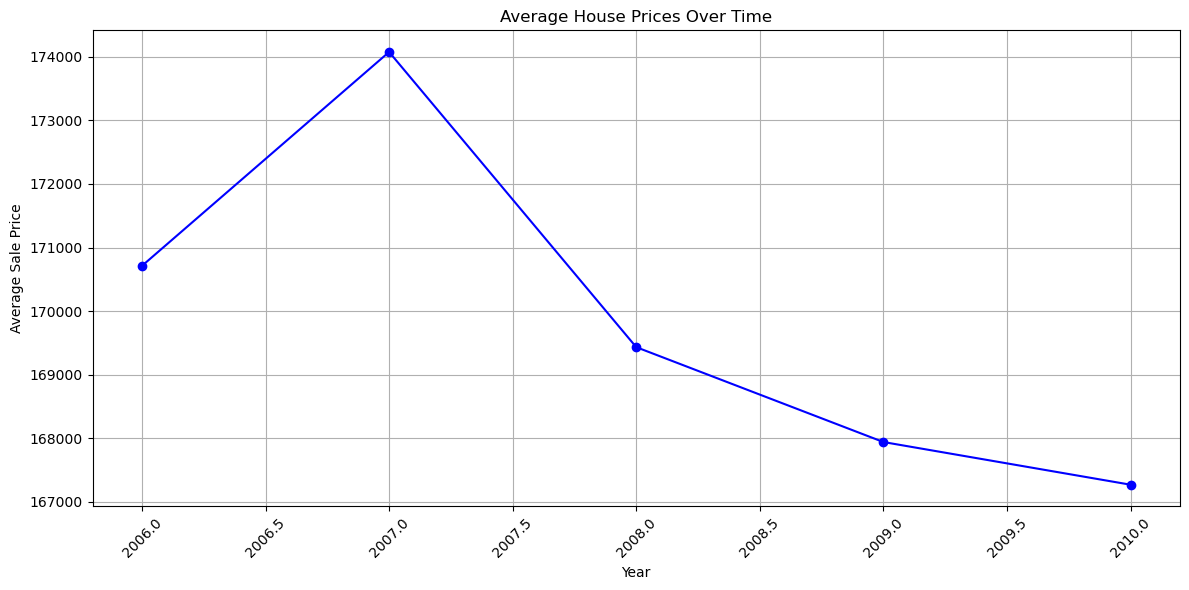

In [1607]:
plt.figure(figsize=(12, 6))
plt.plot(avg_price_by_year.index, avg_price_by_year.values, marker='o', color='b', linestyle='-')
plt.title('Average House Prices Over Time')
plt.xlabel('Year')
plt.ylabel('Average Sale Price')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [1608]:
housing_data.set_index('YrSold', inplace=True)

In [1609]:
import statsmodels.api as sm

In [1610]:
decomposition = sm.tsa.seasonal_decompose(housing_data['SalePrice'], model='additive', period=12)

In [1611]:
decomposition

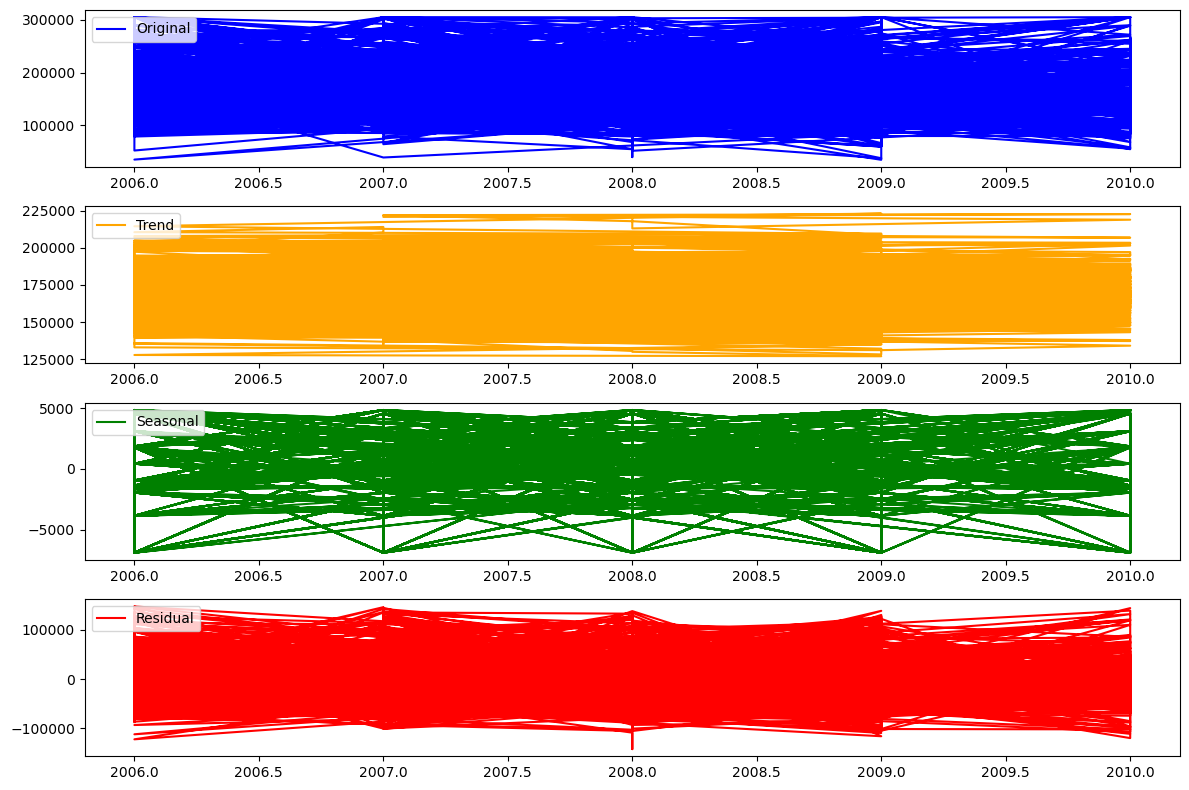

In [1623]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose


# Perform seasonal decomposition
decomposition = seasonal_decompose(housing_data['SalePrice'], model='additive', period=12)

# Plot the decomposition
plt.figure(figsize=(12, 8))

plt.subplot(411)
plt.plot(housing_data['SalePrice'], label='Original', color='blue')
plt.legend(loc='upper left')

plt.subplot(412)
plt.plot(decomposition.trend, label='Trend', color='orange')
plt.legend(loc='upper left')

plt.subplot(413)
plt.plot(decomposition.seasonal, label='Seasonal', color='green')
plt.legend(loc='upper left')

plt.subplot(414)
plt.plot(decomposition.resid, label='Residual', color='red')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()


In [1624]:
print(housing_data.columns)

Index(['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearRemodAdd',
       'MasVnrArea', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF',
       'Low_quality_finished_square_feet', 'GrLivArea', 'BedroomAbvGr',
       'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt',
       'GarageCars', 'GarageArea', 'miscellaneous_feature', 'SalePrice',
       'PricePerSqFt', 'AgeAtSale', 'TotalSqFt', 'TotalBathrooms',
       'TotalPorchArea', 'TotalFinishedSqFt', 'TotalQualityScore',
       'TotalGarageScore', 'TotalOutdoorArea'],
      dtype='object')


In [1625]:
amenities_columns = [ 'GarageArea', 'Fireplaces']

In [1626]:
amenities_data = housing_data[amenities_columns]

In [1627]:
print(amenities_data.head())

        GarageArea  Fireplaces
YrSold                        
2008.0       548.0         0.0
2007.0       460.0         1.0
2008.0       608.0         1.0
2006.0       642.0         1.0
2008.0       836.0         1.0


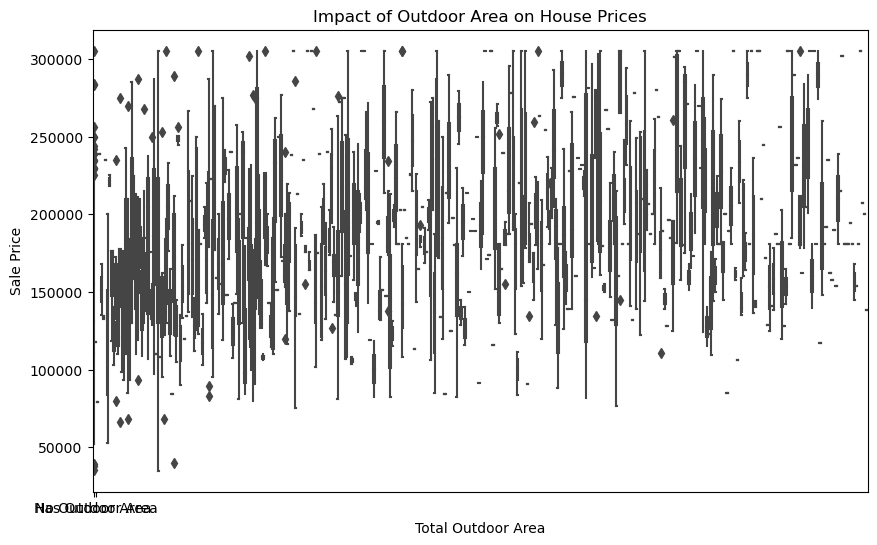

In [1628]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='TotalOutdoorArea', y='SalePrice', data=housing_data)
plt.title('Impact of Outdoor Area on House Prices')
plt.xlabel('Total Outdoor Area')
plt.ylabel('Sale Price')
plt.xticks([0, 1], ['No Outdoor Area', 'Has Outdoor Area'])  # Ensure categories match dataset
plt.show()
